# Settings

In [1]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

2026-05-29 13:27:06,232 - qm - INFO     - Starting session: c0755c8e-e029-4240-b34f-8bc76f3ca4b9


In [175]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.47,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=142.7,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=17300 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "floquet_expt"
)

cfg = qnmr.cfg_from_settings(settings)

# Loschmidt Echo

In [3]:
loschmidt_expt = True # whether to execute Loschmidt echo or just forward evolution

for t0 in (np.linspace(5.0, 7.5, 11)*u.us) :
    print(int(t0))

5000
5250
5500
5750
6000
6250
6500
6750
7000
7250
7500


## Simple test
Demonstrates that we floquet all the way forward then all the way backward
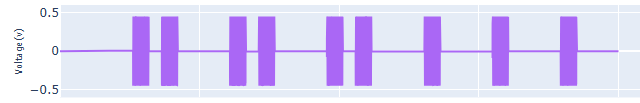

Testing t0=3000 now.
2026-04-01 14:01:32,506 - qm - INFO     - Performing health check
2026-04-01 14:01:32,506 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-01 14:01:32,746 - qm - INFO     - Simulating program.
Experiment with t0=3000 complete!


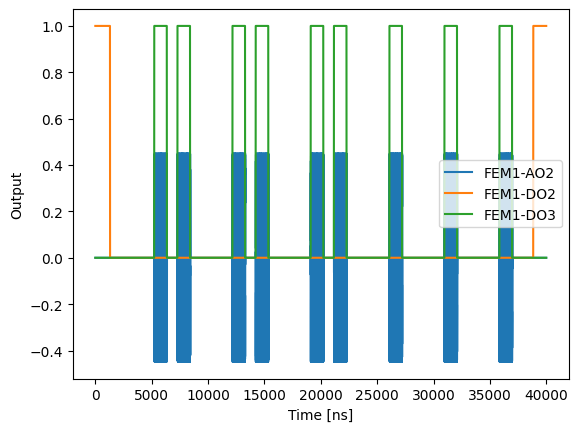

In [32]:
t0=5.0*u.us
p1 = settings.pulse_length
thlf = (t0 - p1) / 2
t1 = t0 - p1
t2 = 2 * t0 - p1

# define experiment object
expt = qnmr.Experiment2D(settings=settings, config=cfg)

fc_elements = (settings.res_key, settings.helper_key)
expt.add_frame_change(angle=-4.0, elements=fc_elements)


# Pine-8 sequence pattern for engineering H=0
dummy1 = np.array([0,0])
dummy1_delays = np.array([t1, thlf, t1])
dummy2 = np.array([90])
dummy2_delays = np.array([t1, t1])

# evolve for up 3 periods
period_list = np.arange(3,25,1)
expt.add_floquet_sequence(phases=dummy1, delays=dummy1_delays, repetitions=period_list)
expt.add_floquet_sequence(phases=dummy2, delays=dummy2_delays, repetitions=period_list)
expt.update_sweep_label("Periods")
expt.update_sweep_axis(period_list)

# expt.execute_experiment()
expt.remove_initial_delay()
expt.simulate_experiment()

print("Experiment with t0=" + str(t0) + " complete!")
# time.sleep(10)


## Pine-8

In [63]:
np.linspace(4.0, 7.5, 8)

array([4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5])

Testing t0=4500 now.
2026-06-04 13:35:59,978 - qm - INFO     - Performing health check
2026-06-04 13:35:59,981 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-04 13:36:00,586 - qm - INFO     - Clearing queue
2026-06-04 13:36:00,586 - qm - INFO     - Adding program to queue.


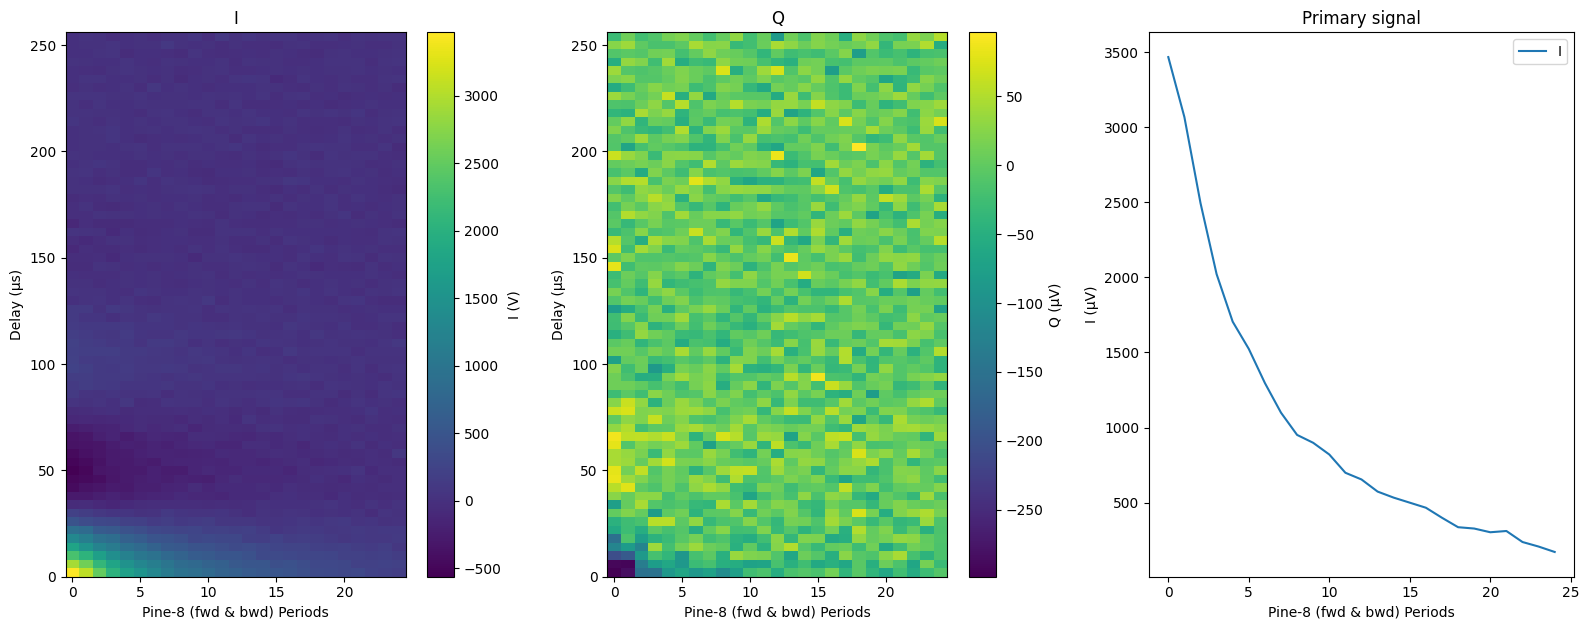

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.43s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.92s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.42s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0039
Experiment with t0=4500 complete!
Testing t0=5000 now.
2026-06-04 13:42:40,834 - qm - INFO     - Performing health check
2026-06-04 13:42:40,852 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-04 13:42:41,517 - qm - INFO     - Clearing queue
2026-06-04 13:42:41,522 - qm - INFO     - Adding program to queue.


KeyboardInterrupt: 

In [65]:
loschmidt_expt = True
# sequence time constants
for t0 in (np.linspace(4.5, 7.5, 7)*u.us) :
    t0 = int(t0)
    print("Testing t0=" + str(t0) + " now.")

    p1 = settings.pulse_length
    thlf = (t0 - p1) / 2
    t1 = t0 - p1
    t2 = 2 * t0 - p1

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-5.0, elements=fc_elements)


    # Pine-8 sequence pattern for engineering H=0
    pine8_phases = np.array([0,0,0,0,180,180,180,180])
    pine8_bw_phases = np.array([90,90,90,90,270,270,270,270])
    pine8_delays = np.array([thlf, t2, t1, t2, t1, t2, t1, t2, thlf])
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,25,1)
    expt.add_floquet_sequence(phases=pine8_phases, delays=pine8_delays, repetitions=period_list)
    expt.update_sweep_label("Pine-8 Periods")
    if loschmidt_expt:
        expt.add_floquet_sequence(phases=pine8_bw_phases, delays=pine8_delays, repetitions=period_list)
        expt.update_sweep_label("Pine-8 (fwd & bwd) Periods")


    expt.add_delay(1*u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)
    
    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with t0=" + str(t0) + " complete!")


[1.13071350e-02 1.60263923e+01 1.84995301e-02]
Completed fitting experiments:
delay=2.5μs -> tau=822.587μs
delay=3.0μs -> tau=844.400μs
delay=3.5μs -> tau=835.534μs
delay=4.0μs -> tau=838.102μs
delay=4.5μs -> tau=820.076μs
delay=5.0μs -> tau=817.396μs
delay=5.5μs -> tau=811.917μs
delay=6.0μs -> tau=821.310μs
delay=6.5μs -> tau=808.155μs
delay=7.0μs -> tau=808.443μs
delay=7.5μs -> tau=805.094μs


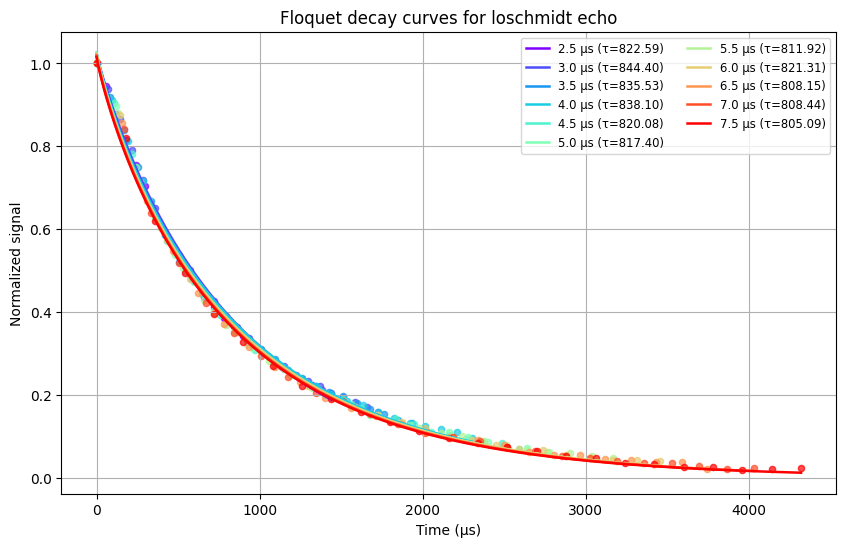

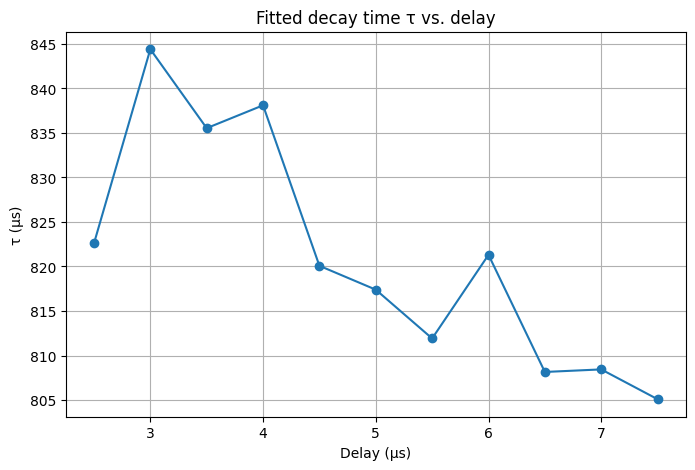

In [486]:
delay_us = np.arange(2.5, 7.6, 0.5)
experiment_ids = np.arange(19, 30)

if len(delay_us) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

colors = plt.cm.rainbow(np.linspace(0, 1, len(delay_us)))

def stretched_exp(x, A, tau, beta):
    return A * np.exp(-(x / tau) ** beta)

all_taus = []
all_delays = []

fig, ax = plt.subplots(figsize=(10, 6))

for delay, exp_id, color in zip(delay_us, experiment_ids, colors):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0] / re[0, 0]

    time = periods * (24 * delay)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, pcov = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.0], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    all_taus.append(tau_fit)
    all_delays.append(delay)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, amplitude_fit, tau_fit, beta_fit)

    ax.scatter(time, signal, color=color, s=20, alpha=0.7)
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8,
            label=f"{delay:.1f} μs (τ={tau_fit:.2f})")

ax.set_title("Floquet decay curves for loschmidt echo")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Normalized signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

print(np.sqrt(np.diag(pcov)))
fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_delays, all_taus, marker="o", linestyle="-", color="tab:blue")
# ax_tau.errorbar(all_delays, all_taus, yerr=np.sqrt(np.diag(pcov)), fmt="o", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for delay, tau in zip(all_delays, all_taus):
    print(f"delay={delay:.1f}μs -> tau={tau:.3f}μs")

[1.87794376e-02 2.18879151e+01 2.77354606e-02]
Completed fitting experiments:
delay=4.0μs -> tau=693.295μs
delay=4.5μs -> tau=675.996μs


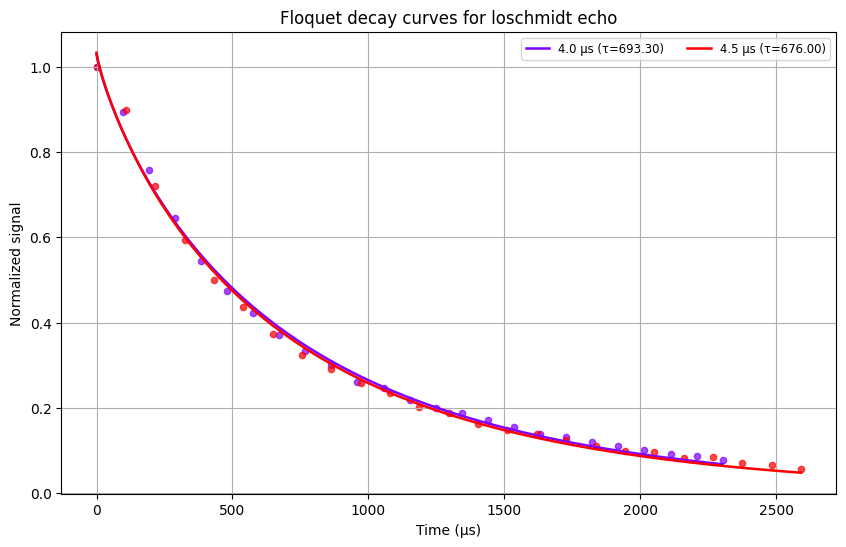

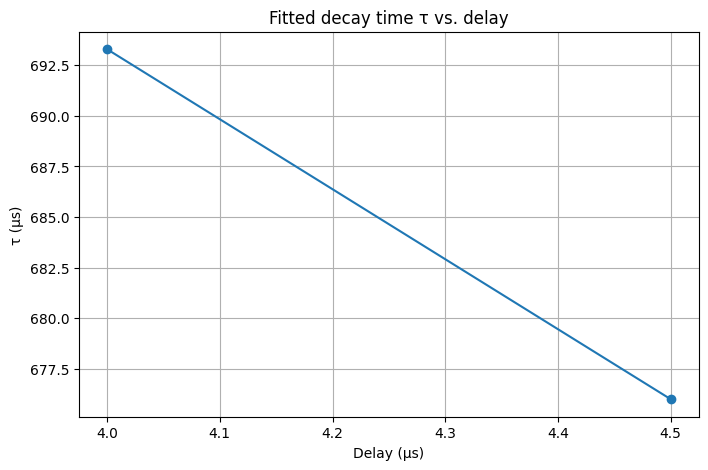

In [66]:
#Repeat expt
delay_us = np.arange(4, 4.6, 0.5)
experiment_ids = np.arange(38, 40)

if len(delay_us) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

colors = plt.cm.rainbow(np.linspace(0, 1, len(delay_us)))

def stretched_exp(x, A, tau, beta):
    return A * np.exp(-(x / tau) ** beta)

all_taus = []
all_delays = []

fig, ax = plt.subplots(figsize=(10, 6))

for delay, exp_id, color in zip(delay_us, experiment_ids, colors):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0] / re[0, 0]

    time = periods * (24 * delay)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, pcov = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.0], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    all_taus.append(tau_fit)
    all_delays.append(delay)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, amplitude_fit, tau_fit, beta_fit)

    ax.scatter(time, signal, color=color, s=20, alpha=0.7)
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8,
            label=f"{delay:.1f} μs (τ={tau_fit:.2f})")

ax.set_title("Floquet decay curves for loschmidt echo")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Normalized signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

print(np.sqrt(np.diag(pcov)))
fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_delays, all_taus, marker="o", linestyle="-", color="tab:blue")
# ax_tau.errorbar(all_delays, all_taus, yerr=np.sqrt(np.diag(pcov)), fmt="o", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for delay, tau in zip(all_delays, all_taus):
    print(f"delay={delay:.1f}μs -> tau={tau:.3f}μs")

## Wei16

In [ ]:
t0 = 5.0 * u.us
# u0=1; v=0; w=0 # DQ Hamiltonian
u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
a=0; b=0; c=0
c2 = .1
u0*=c2; v*=c2; w*=c2

print(f"",(u0-w),"SxSx + ",(v-u0),"SySy + ",(w-v),"SzSz")
p1 = settings.pulse_length
t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
t1e = t1 + (p1/2) # starting and ending t1 accounts for p1 subtraction below

# Pine-8 sequence pattern for engineering H=0
wei16_phases = np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                         t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
print(wei16_delays)

total=0
print("Total sequence time: ", np.sum(wei16_delays))

 0.0 SxSx +  0.0 SySy +  0.0 SzSz
[4380. 3760. 8760. 3760. 8760. 3760. 8760. 3760. 8760. 3760. 8760. 3760.
 8760. 3760. 8760. 3760. 4380.]
Total sequence time:  100160.0


In [44]:
np.linspace(-0.05, 0.05, 11)

array([-0.05, -0.04, -0.03, -0.02, -0.01,  0.  ,  0.01,  0.02,  0.03,
        0.04,  0.05])

Testing c2=-0.05 now.
2026-04-27 20:24:10,605 - qm - INFO     - Performing health check
2026-04-27 20:24:10,611 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:24:11,832 - qm - INFO     - Clearing queue
2026-04-27 20:24:11,842 - qm - INFO     - Adding program to queue.


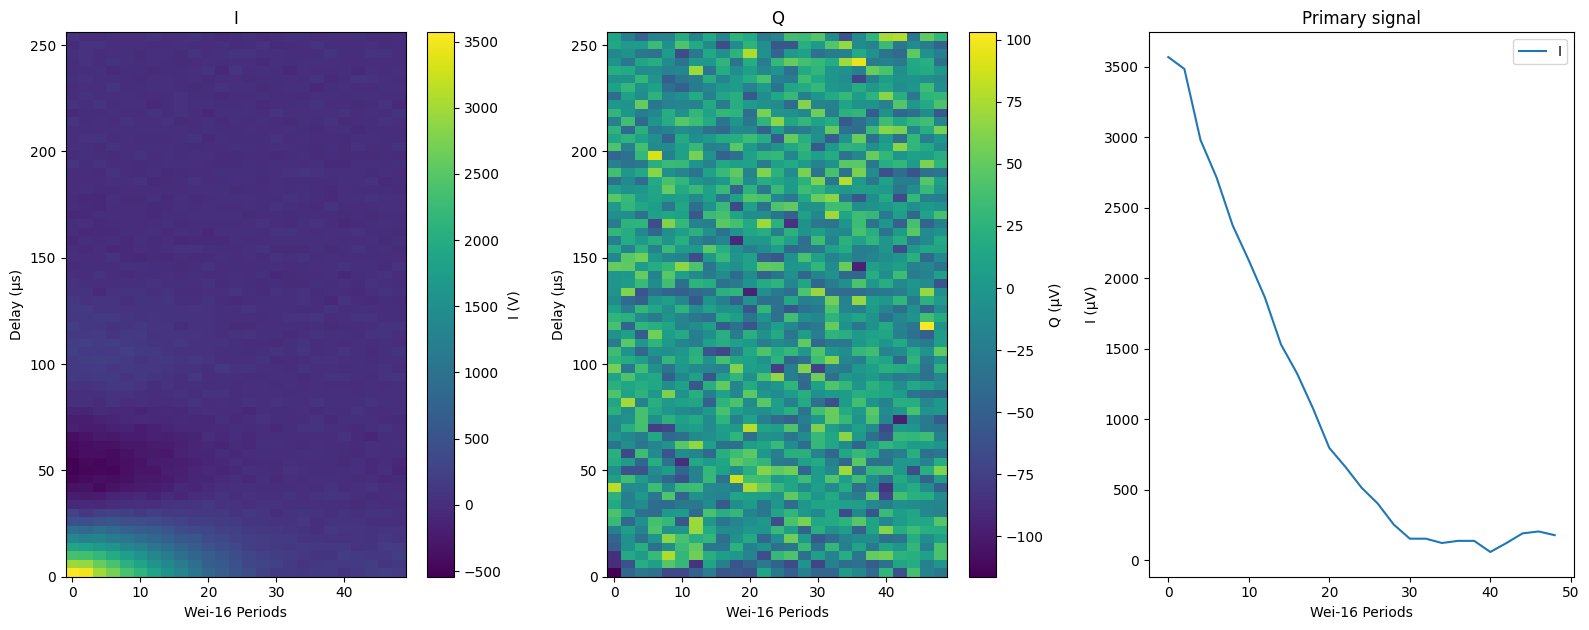

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.54s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.11s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0024
Experiment with c2=-0.05 complete!
Testing c2=-0.04 now.
2026-04-27 20:31:01,729 - qm - INFO     - Performing health check
2026-04-27 20:31:01,733 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:31:02,402 - qm - INFO     - Clearing queue
2026-04-27 20:31:02,408 - qm - INFO     - Adding program to queue.


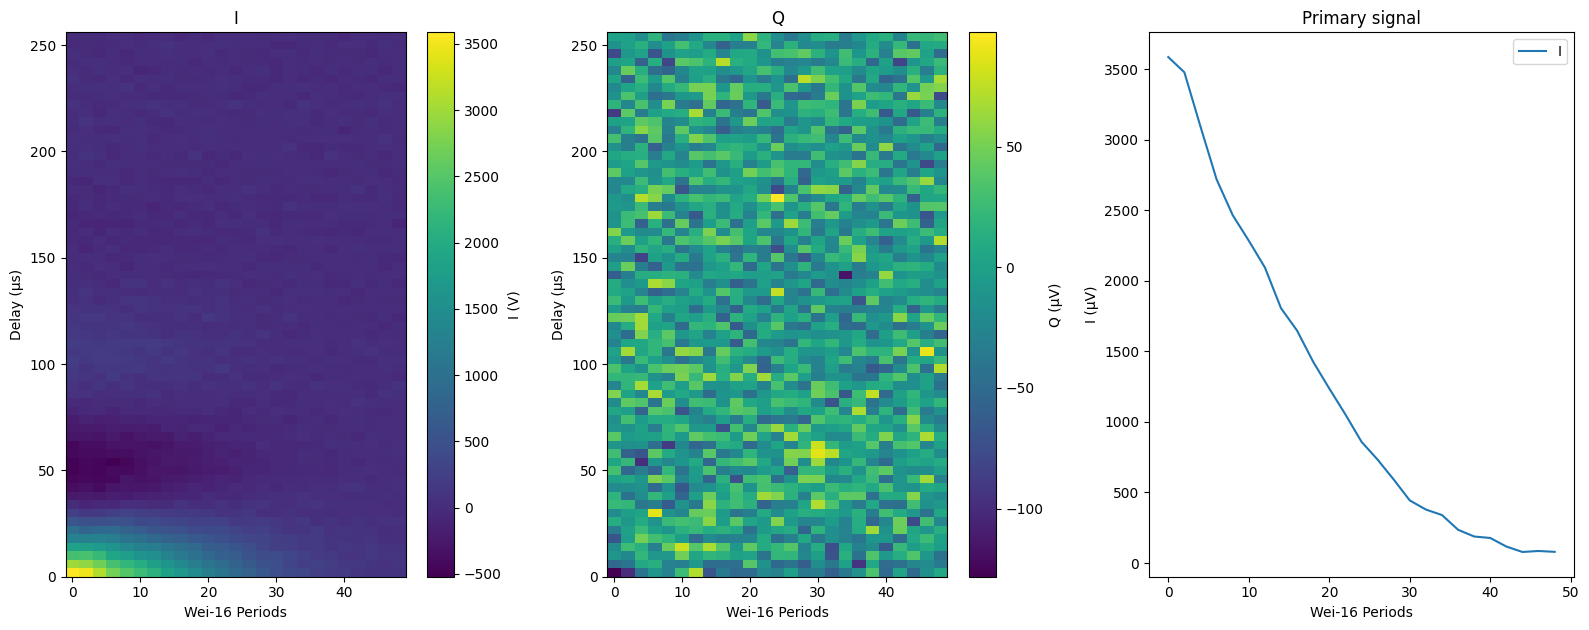

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.37s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.21s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0025
Experiment with c2=-0.04 complete!
Testing c2=-0.03 now.
2026-04-27 20:37:52,631 - qm - INFO     - Performing health check
2026-04-27 20:37:52,635 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:37:53,310 - qm - INFO     - Clearing queue
2026-04-27 20:37:53,318 - qm - INFO     - Adding program to queue.


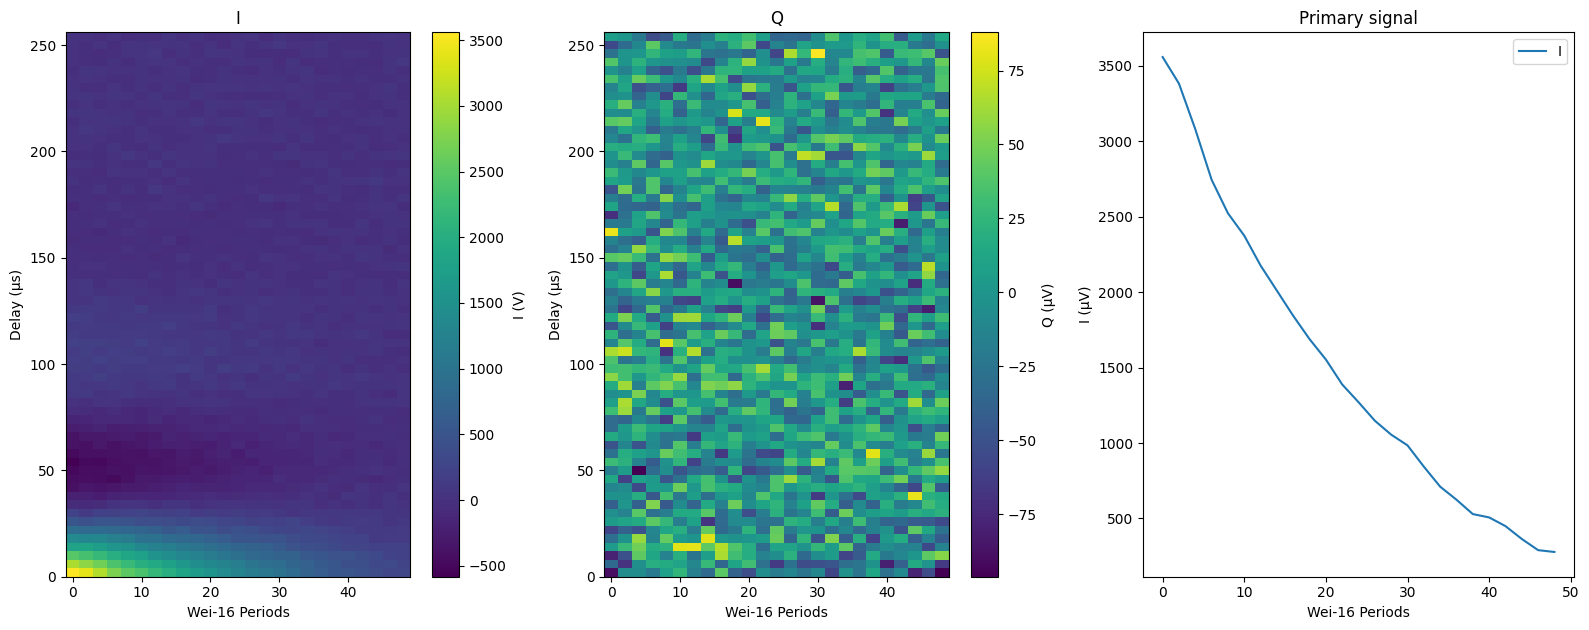

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.72s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.22s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0026
Experiment with c2=-0.03 complete!
Testing c2=-0.02 now.
2026-04-27 20:44:43,335 - qm - INFO     - Performing health check
2026-04-27 20:44:43,339 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:44:43,918 - qm - INFO     - Clearing queue
2026-04-27 20:44:43,924 - qm - INFO     - Adding program to queue.


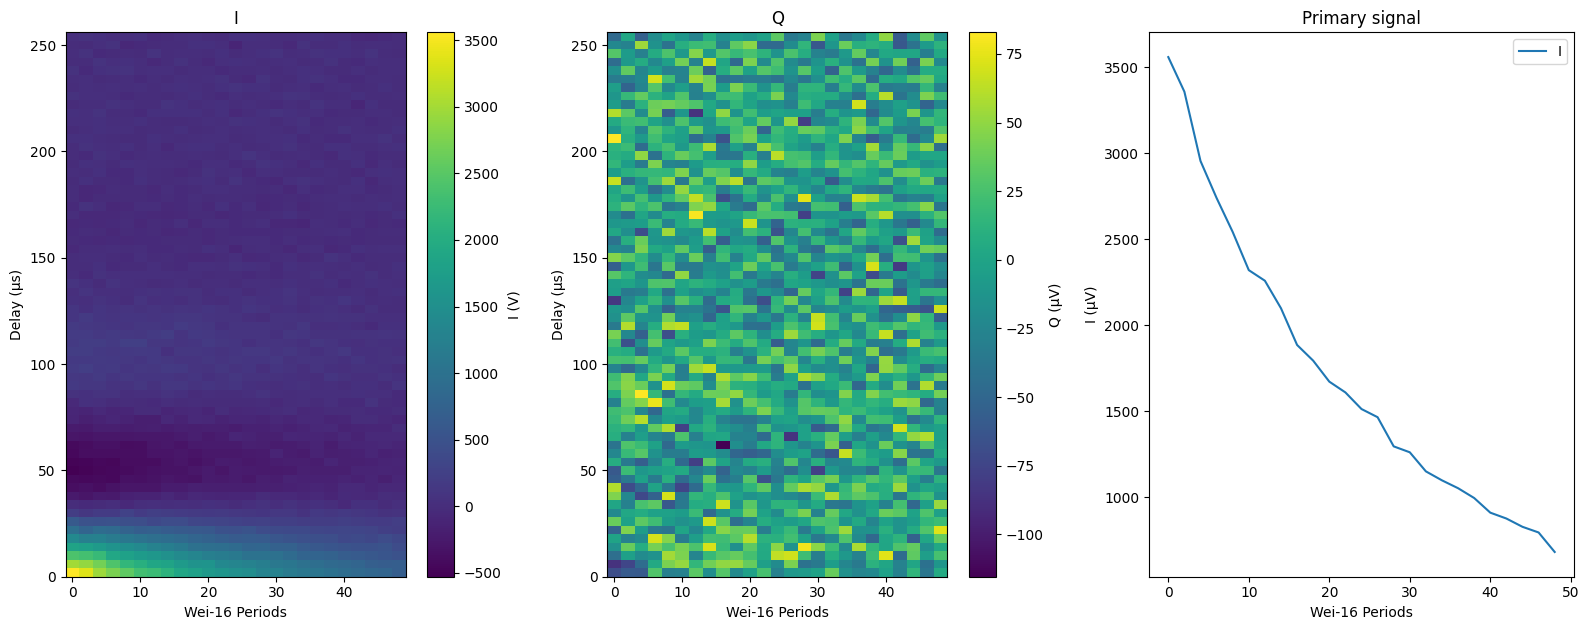

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.35s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.84s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.36s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0027
Experiment with c2=-0.02 complete!
Testing c2=-0.01 now.
2026-04-27 20:51:34,039 - qm - INFO     - Performing health check
2026-04-27 20:51:34,043 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:51:34,662 - qm - INFO     - Clearing queue
2026-04-27 20:51:34,671 - qm - INFO     - Adding program to queue.


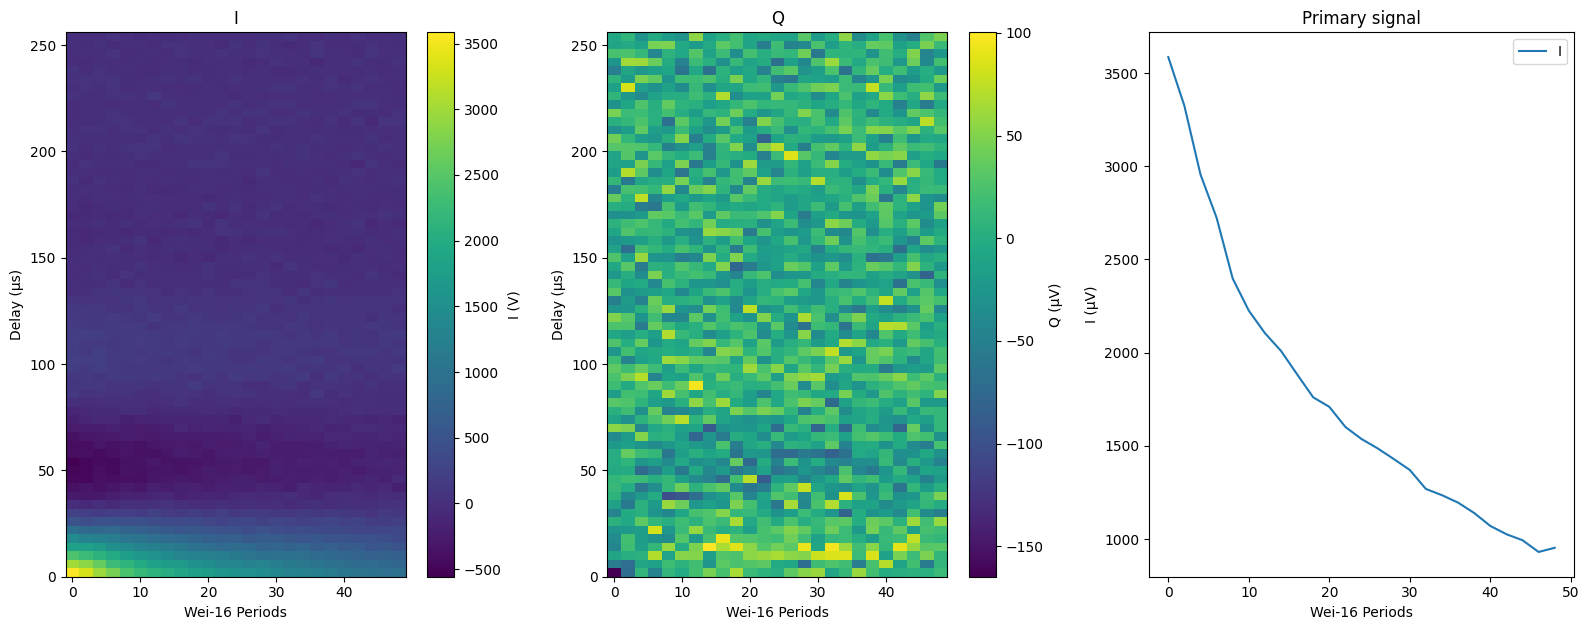

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.26s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.76s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.28s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0028
Experiment with c2=-0.01 complete!
Testing c2=0.0 now.
2026-04-27 20:58:24,817 - qm - INFO     - Performing health check
2026-04-27 20:58:24,820 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 20:58:25,415 - qm - INFO     - Clearing queue
2026-04-27 20:58:25,425 - qm - INFO     - Adding program to queue.


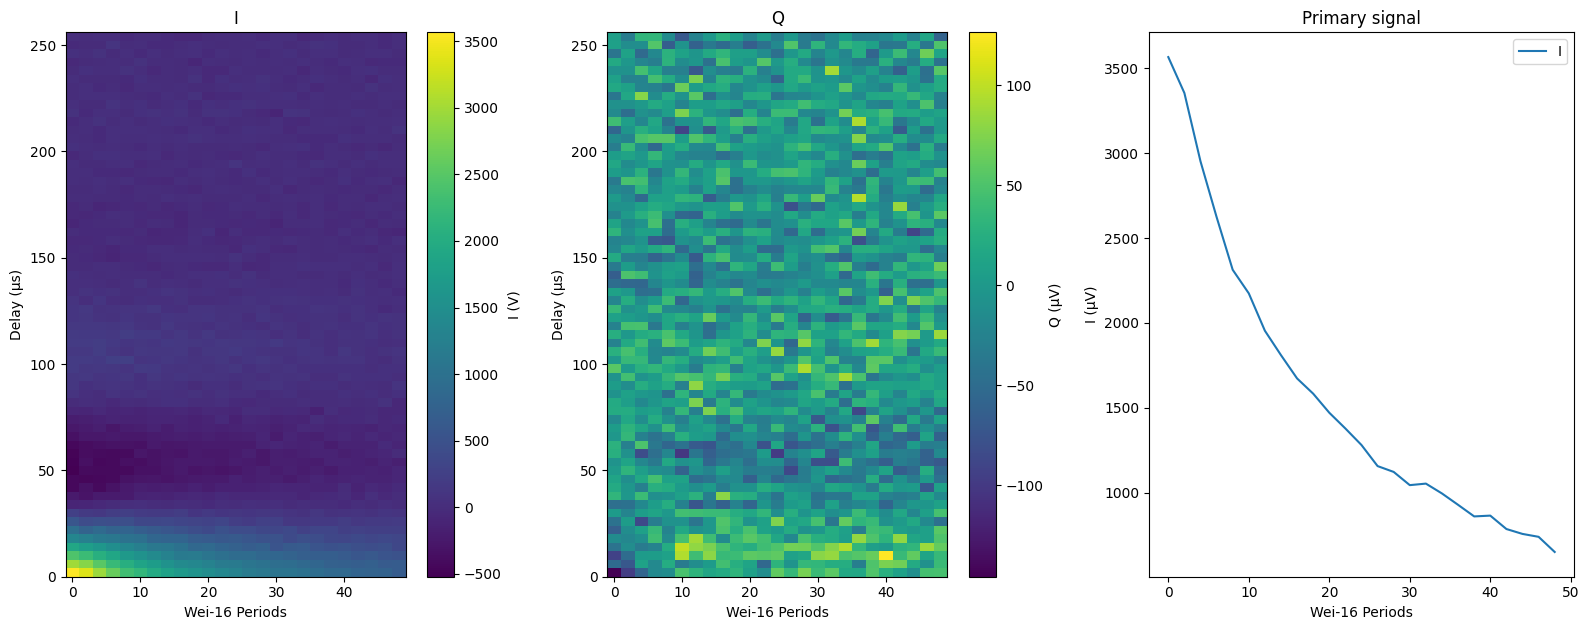

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.43s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.96s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0029
Experiment with c2=0.0 complete!
Testing c2=0.01 now.
2026-04-27 21:05:15,155 - qm - INFO     - Performing health check
2026-04-27 21:05:15,158 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 21:05:15,787 - qm - INFO     - Clearing queue
2026-04-27 21:05:15,793 - qm - INFO     - Adding program to queue.


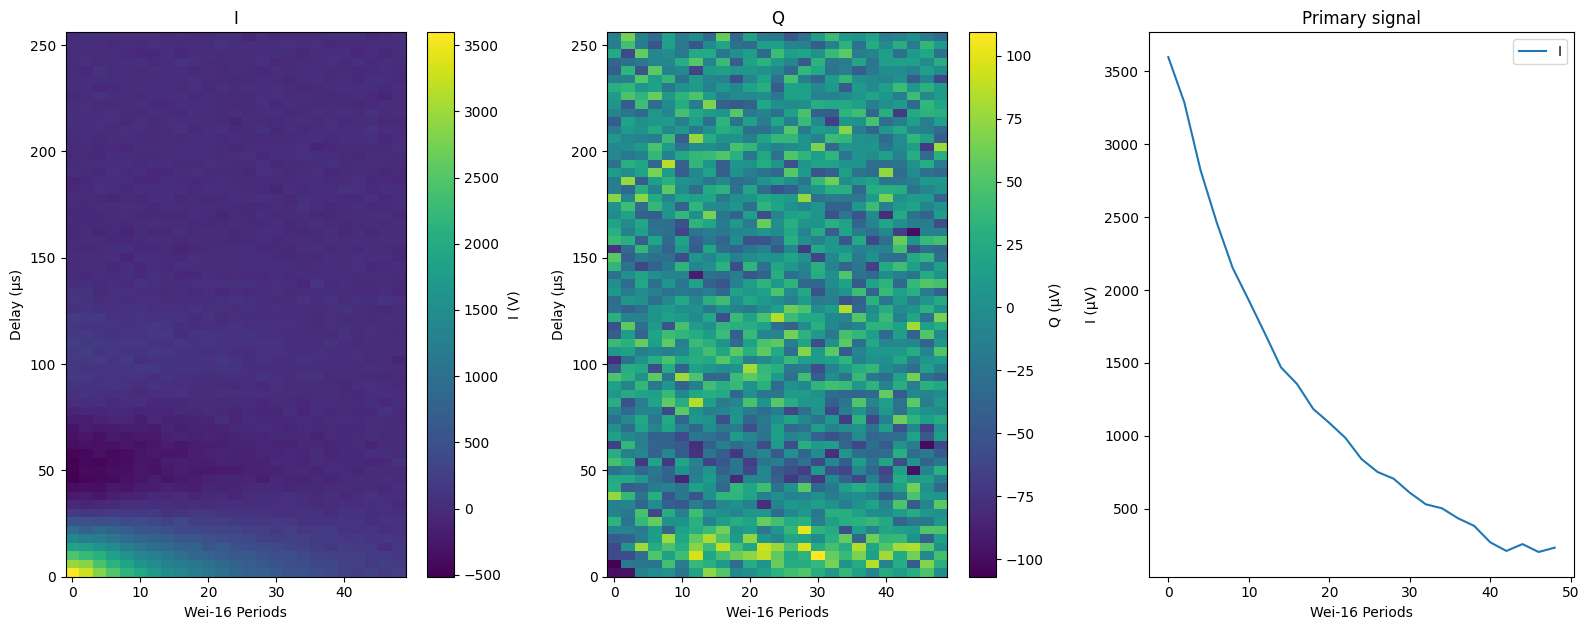

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.22s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.79s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.37s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0030
Experiment with c2=0.01 complete!
Testing c2=0.02 now.
2026-04-27 21:12:05,956 - qm - INFO     - Performing health check
2026-04-27 21:12:05,959 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 21:12:06,566 - qm - INFO     - Clearing queue
2026-04-27 21:12:06,572 - qm - INFO     - Adding program to queue.


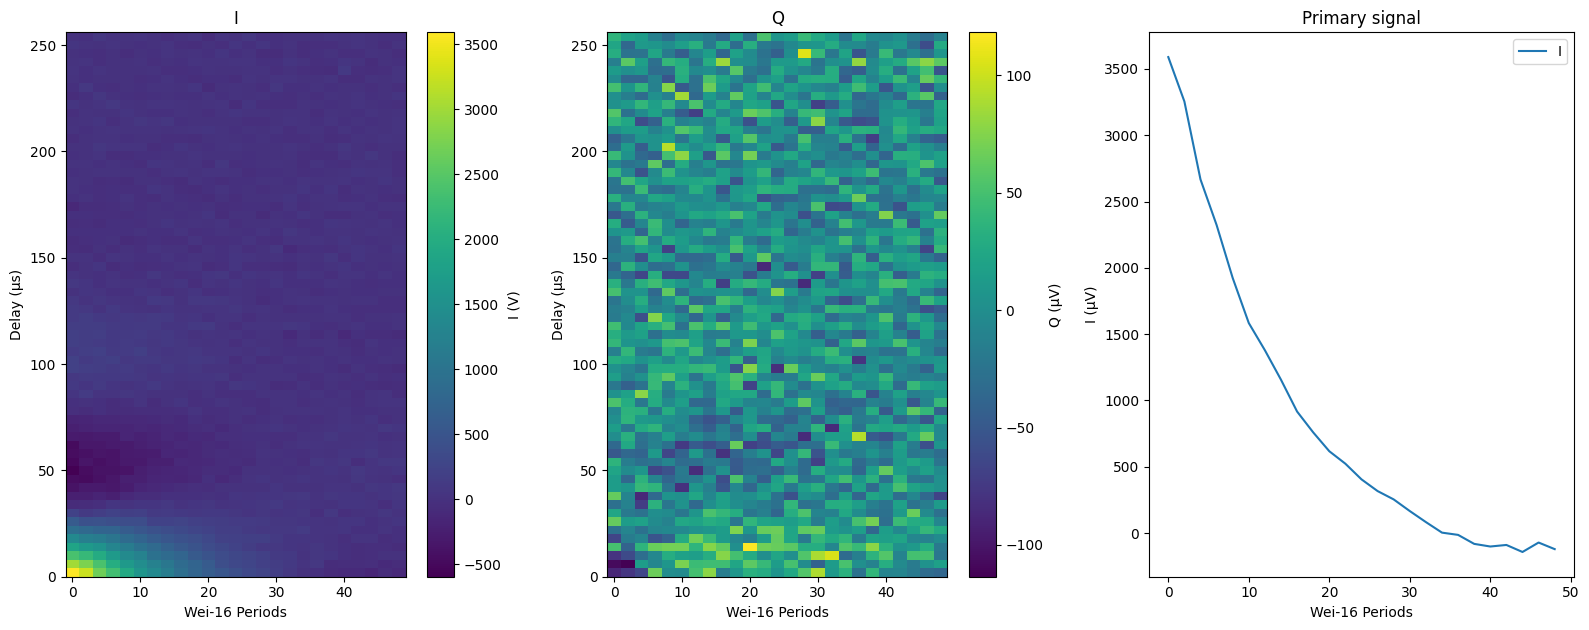

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.26s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.82s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0031
Experiment with c2=0.02 complete!
Testing c2=0.03 now.
2026-04-27 21:18:56,469 - qm - INFO     - Performing health check
2026-04-27 21:18:56,472 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 21:18:57,105 - qm - INFO     - Clearing queue
2026-04-27 21:18:57,112 - qm - INFO     - Adding program to queue.


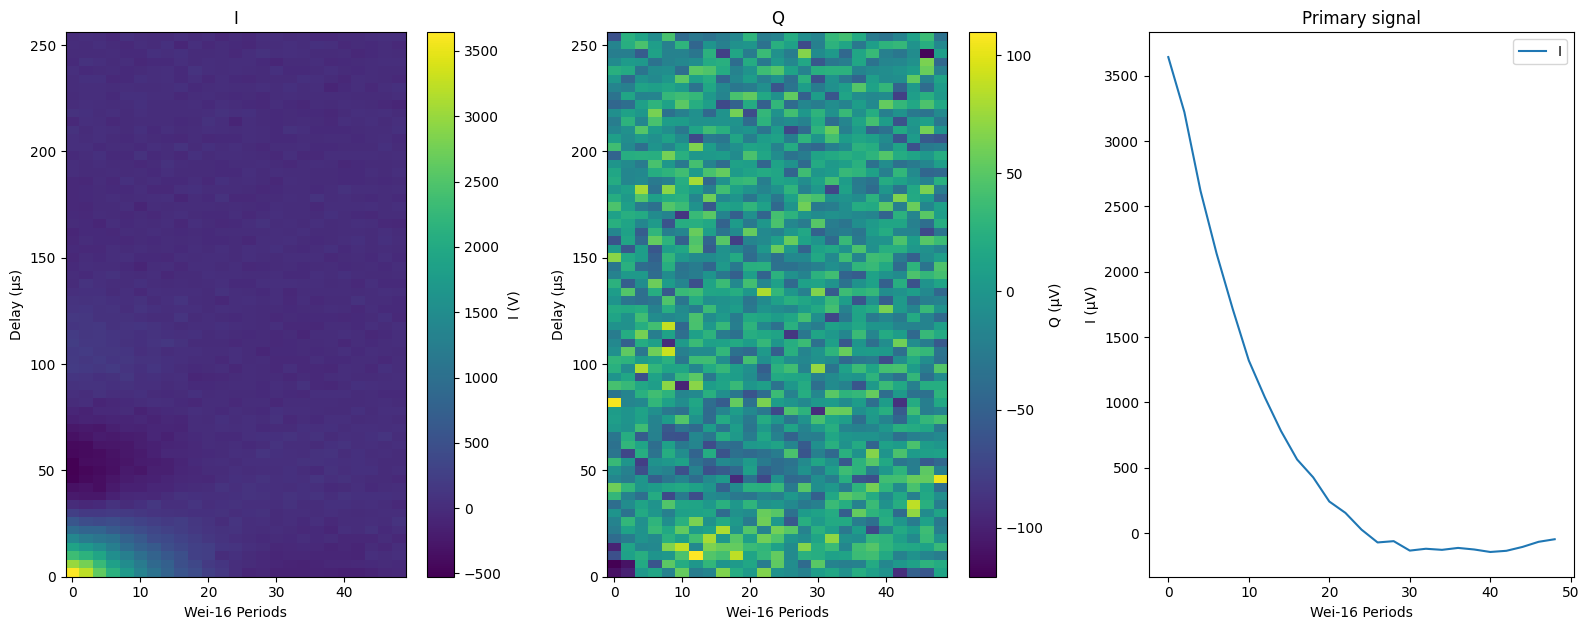

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.41s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.93s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0032
Experiment with c2=0.03 complete!
Testing c2=0.04 now.
2026-04-27 21:25:46,753 - qm - INFO     - Performing health check
2026-04-27 21:25:46,757 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 21:25:47,370 - qm - INFO     - Clearing queue
2026-04-27 21:25:47,381 - qm - INFO     - Adding program to queue.


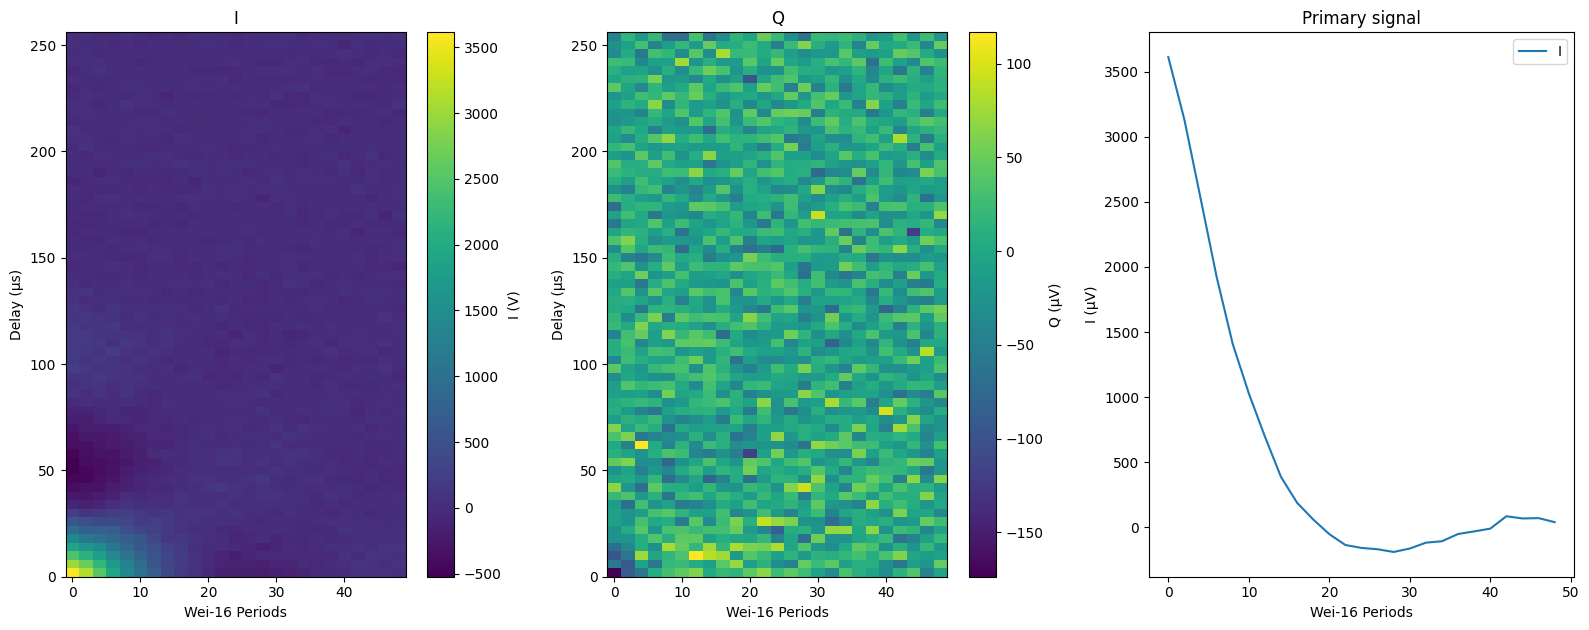

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.30s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.82s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0033
Experiment with c2=0.04 complete!
Testing c2=0.05 now.
2026-04-27 21:32:36,975 - qm - INFO     - Performing health check
2026-04-27 21:32:36,979 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-27 21:32:37,590 - qm - INFO     - Clearing queue
2026-04-27 21:32:37,596 - qm - INFO     - Adding program to queue.


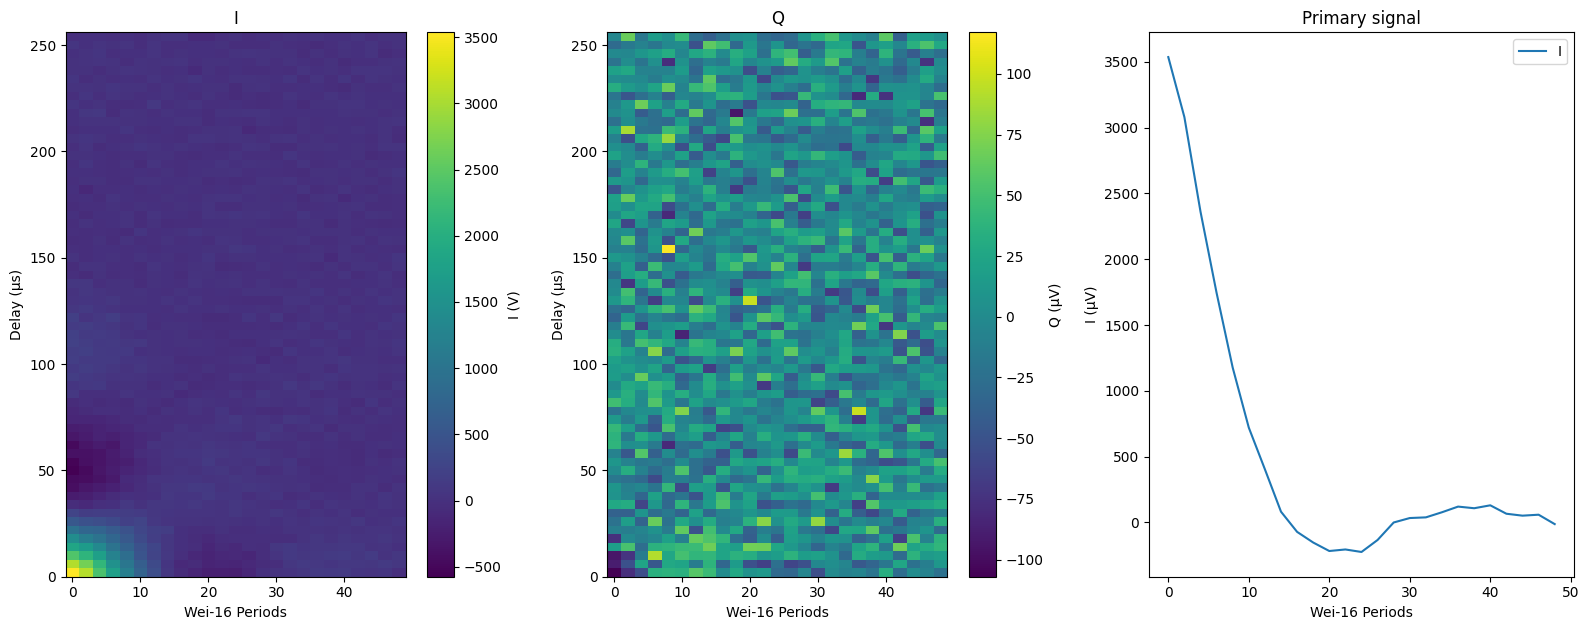

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.46s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.00s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0034
Experiment with c2=0.05 complete!


In [ ]:
rho0 = "X" # whether to start in X or Z state for the experiment

for c2 in (-0.05, -0.04, -0.03, -0.02, -0.01, 0.0, 0.01, 0.02, 0.03, 0.04, 0.05):
    print("Testing c2=" + str(c2) + " now.")

    t0 = 5.0 * u.us
    # u0=1; v=0; w=0 # DQ Hamiltonian
    u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
    a=0; b=0; c=0
    u0*=c2; v*=c2; w*=c2

    p1 = settings.pulse_length
    t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
    t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
    t1e = t1 + (p1/2) # start & end t1.

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-6.5, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if rho0 == "X": expt.add_pulse(phase=90, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=0, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_bw_phases = np.array([90,0,0,90,  90,0,0,90,  270,180,180,270,  270,180,180,270])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,50,2)
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    # if loschmidt_expt:
        # expt.add_floquet_sequence(phases=wei16_bw_phases, delays=wei16_delays, repetitions=period_list)
        # expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5*u.us)
    if rho0 == "X": expt.add_pulse(phase=270, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=180, element=settings.res_key)
    elif rho0 == "Z": pass

    expt.add_delay(1*u.ms)
    expt.add_pulse(element=settings.res_key)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with c2=" + str(c2) + " complete!")
    time.sleep(10)


In [15]:
data_path = settings.save_dir / "wei16/experiment_0028/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
c02signal = re[:, 0]

[-0.   -0.01 -0.02 -0.03 -0.04 -0.05]
Exp 29 | c2=0.00 | A=1.197, b1=23.969, b2=-15.552, c=56.710, d=29.617, e=19.263
Exp 30 | c2=0.01 | A=1.071, b1=11.329, b2=-9.168, c=54.994, d=60.278, e=34.244
Exp 31 | c2=0.02 | A=1.093, b1=9.924, b2=-13.131, c=25.196, d=21.272, e=9.907
Exp 32 | c2=0.03 | A=1.037, b1=-2.857, b2=-39.960, c=27.400, d=9999.189, e=61.138
Exp 33 | c2=0.04 | A=1.025, b1=-1.428, b2=-1.028, c=19.882, d=59.858, e=46.592
Exp 34 | c2=0.05 | A=1.020, b1=-1.080, b2=4.574, c=16.332, d=30.060, e=40.145


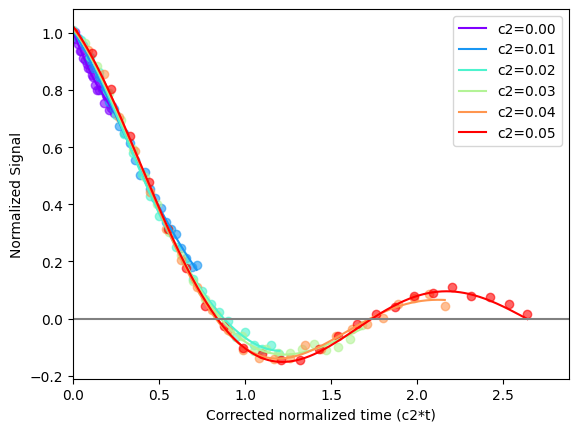

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json

# ---- Gaussian Sinc fit function ----
def damped_moment(t, A, b1, b2, c, d, e):
    fid = A * np.sinc((t-b1)/c) * np.exp(((t-b2)/d)**2 / 2) * np.exp(-t / e)
    return np.array(fid, dtype=float)

# ---- Experiment range ----
exp_ids = list(range(29, 35))  # 24 through 34
c2_values = -1 * np.arange(0.00, 0.06, 0.01)  # -0.05 to 0.05
print(c2_values)

# ---- Colors (red → purple) ----
colors = plt.cm.rainbow(np.linspace(0, 1, len(exp_ids)))

plt.figure()

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"wei16/experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    signal = re[:, 0] / c02signal

    # ---- Fit ----
    popt, _ = curve_fit(
        damped_moment,
        periods,
        signal,
        p0=[1.0, 0, 0, 10, 10, 1],
        bounds=([1, -50, -50, 0, 0, 0],[1.2, 50, 50, 1000, 10000, 9999999])
    )

    # ---- Fit curve ----
    x_fit = np.linspace(min(periods), max(periods), 500)
    y_fit = damped_moment(x_fit, *popt)

    # ---- Plot ----
    label = f"c2={-c2_values[i]:.2f}"
    plt.scatter(abs(c2_values[i]-.005) * periods, signal, color=colors[i], alpha=0.6)
    plt.plot(abs(c2_values[i]-.005) * x_fit, y_fit, color=colors[i], label=label)

    print(f"Exp {exp_id} | c2={abs(c2_values[i]):.2f} | "
          f"A={popt[0]:.3f}, b1={popt[1]:.3f}, b2={popt[2]:.3f}, c={popt[3]:.3f}, d={popt[4]:.3f}, e={popt[5]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(.06*periods))
plt.xlabel("Corrected normalized time (c2*t)")
plt.ylabel("Normalized Signal")

plt.show()

[-5.0000000e-02 -4.0000000e-02 -3.0000000e-02 -2.0000000e-02
 -1.0000000e-02  6.9388939e-18  1.0000000e-02  2.0000000e-02
  3.0000000e-02  4.0000000e-02  5.0000000e-02]


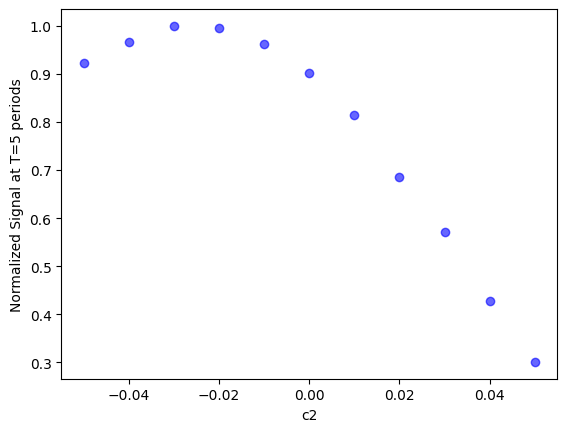

In [18]:
# ---- Parabola fit function ----
def Parabola(t, A, t0, b):
    return A * (np.abs(t-t0)**2) + b


# ---- Experiment range ----
exp_ids = list(range(24, 35))  # 24 through 34
c2_values = np.arange(-0.05, 0.06, 0.01)  # -0.5 to 0.5
print(c2_values)

plt.figure()

T5signal = np.empty(len(exp_ids), dtype=float)

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"wei16/experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    T5signal[i] = re[5,0]

plt.scatter(c2_values, T5signal/np.max(T5signal), color='blue', alpha=0.6)
plt.xlabel("c2")
plt.ylabel("Normalized Signal at T=5 periods")

# x_fit = np.linspace(min(c2_values), max(c2_values), 500)
# popt, pcov = curve_fit(Parabola, c2_values, T5signal, p0=[-2500.0, 0.2, 2500], maxfev=10000)
# y_fit = Parabola(x_fit, *popt)
# plt.plot(x_fit, Parabola(x_fit, *popt), color='red', label=f"Fit: A={popt[0]:.2f}, t0={popt[1]:.2f}, b={popt[2]:.2f}")
# plt.legend()

plt.show()

### Fitting

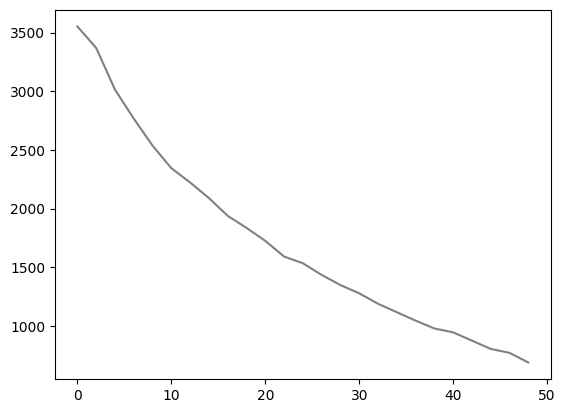

In [311]:
plt.plot(periods, c02signal, color='gray')  # baseline

### Wei16 Echo

In [405]:
print(np.linspace(5, 10, 3))

[ 5.   7.5 10. ]


In [ ]:
rho0 = "X" # whether to start in X or Z state for the experiment

for c2 in (-0.05, -0.04, -0.03, -0.02, -0.01, 0.0, 0.01, 0.02, 0.03, 0.04, 0.05):
    print("Testing c2=" + str(c2) + " now.")

    t0 = 5.0 * u.us
    # u0=1; v=0; w=0 # DQ Hamiltonian
    u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
    a=0; b=0; c=0
    u0*=c2; v*=c2; w*=c2

    p1 = settings.pulse_length
    t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
    t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
    t1e = t1 + (p1/2) # start & end t1.

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-6.5, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if rho0 == "X": expt.add_pulse(phase=90, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=0, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_bw_phases = np.array([90,0,0,90,  90,0,0,90,  270,180,180,270,  270,180,180,270])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,50,2)
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    # if loschmidt_expt:
        # expt.add_floquet_sequence(phases=wei16_bw_phases, delays=wei16_delays, repetitions=period_list)
        # expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5*u.us)
    if rho0 == "X": expt.add_pulse(phase=270, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=180, element=settings.res_key)
    elif rho0 == "Z": pass

    expt.add_delay(1*u.ms)
    expt.add_pulse(element=settings.res_key)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with c2=" + str(c2) + " complete!")
    time.sleep(10)


In [413]:
# u0=1; v=0; w=0 # DQ Hamiltonian
uα=0; vα=-0.5; wα=0.5 # Dipole Hamiltonian
uβ=0; vβ=0.5; wβ=-0.5 # Dipole Hamiltonian
a=0; b=0; c=0
c2=.05
uα*=c2; vα*=c2; wα*=c2
uβ*=c2; vβ*=c2; wβ*=c2

p1 = settings.pulse_length
t1 = t0*(1-c-vα+wα);   t2 = t0*(1+b-uα+vα);   t3 = t0*(1-a+uα-wα)
t1p = t0*(1-c-vα+wα);  t2p = t0*(1-b-uα+vα);  t3p = t0*(1-a+uα-wα)
t1e = t1 + (p1/2) # start & end t1.

t1β = t0*(1-c-vβ+wβ);   t2β = t0*(1+b-uβ+vβ);   t3β = t0*(1-a+uβ-wβ)
t1pβ = t0*(1-c-vβ+wβ);  t2pβ = t0*(1-b-uβ+vβ);  t3pβ = t0*(1-a+uβ-wβ)
t1eβ = t1β + (p1/2) # start & end t1.
print(t1, t2, t3, t1p, t2p, t3p, t1e)
print(t1β, t2β, t3β, t1pβ, t2pβ, t3pβ, t1eβ)

5249.999999999999 4875.0 4875.0 5249.999999999999 4875.0 4875.0 5859.999999999999
4750.0 5125.0 5125.0 4750.0 5125.0 5125.0 5360.0


Testing t0=5000.0 now.
2026-04-28 14:09:40,846 - qm - INFO     - Performing health check
2026-04-28 14:09:40,850 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-28 14:09:41,979 - qm - INFO     - Clearing queue
2026-04-28 14:09:42,004 - qm - INFO     - Adding program to queue.


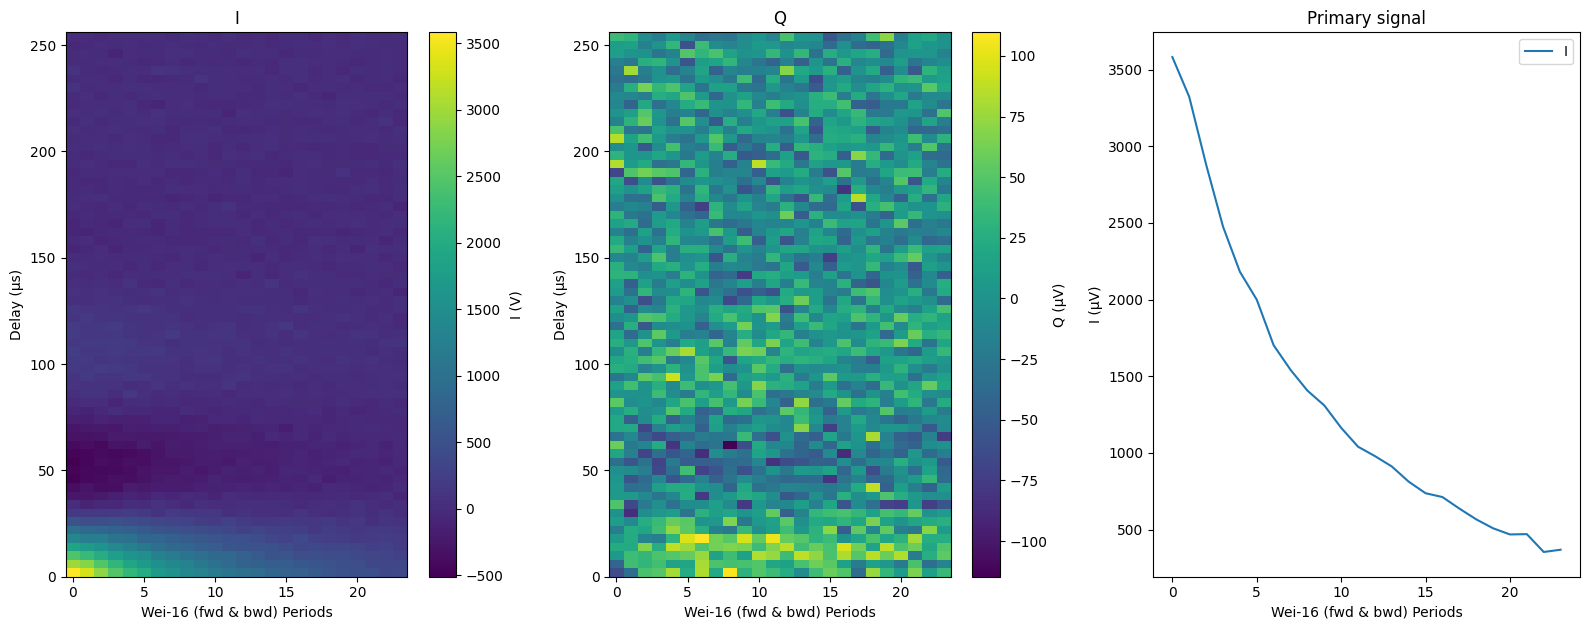

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 288.50s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 289.04s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0035
Experiment with t0=5000.0 complete!
Testing t0=7500.0 now.
2026-04-28 14:16:16,159 - qm - INFO     - Performing health check
2026-04-28 14:16:16,162 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-28 14:16:17,007 - qm - INFO     - Clearing queue
2026-04-28 14:16:17,013 - qm - INFO     - Adding program to queue.


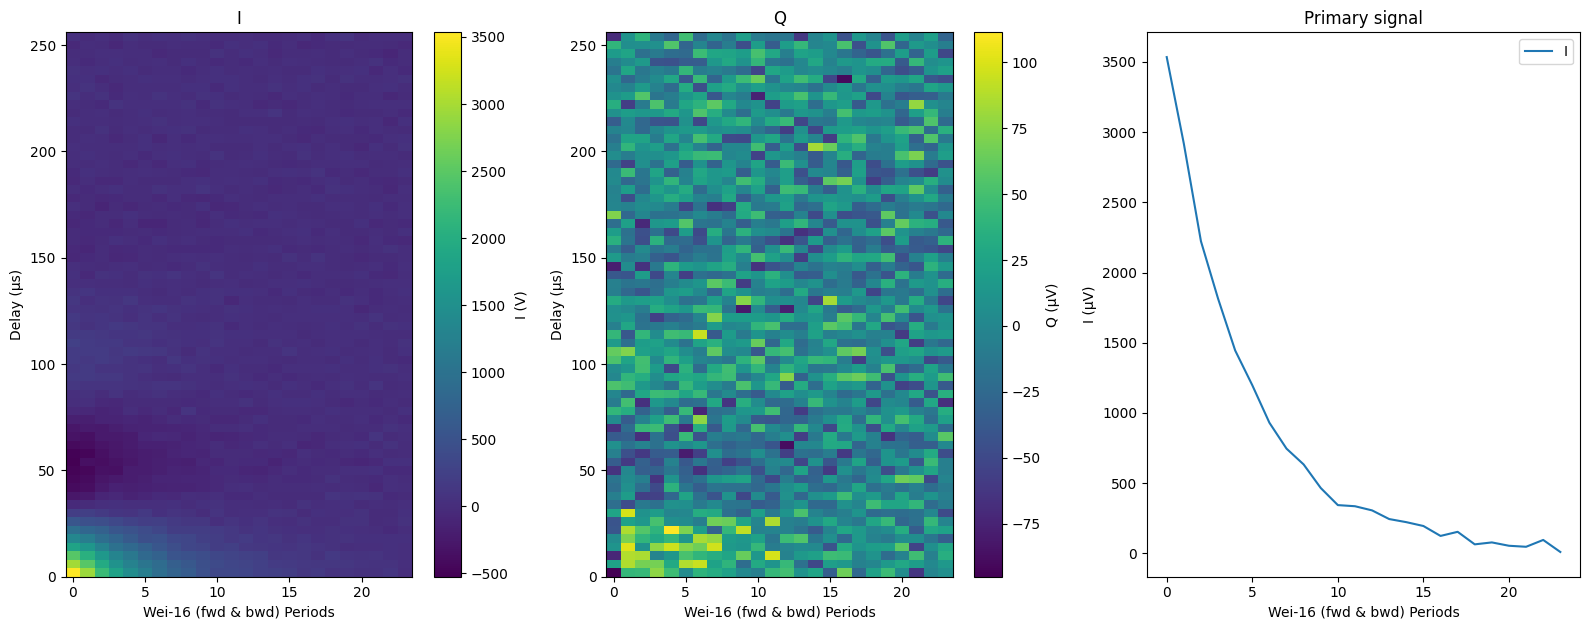

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 288.40s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 288.91s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0036
Experiment with t0=7500.0 complete!
Testing t0=10000.0 now.
2026-04-28 14:22:50,916 - qm - INFO     - Performing health check
2026-04-28 14:22:50,919 - qm - INFO     - Cluster healthcheck completed successfully.
2026-04-28 14:22:51,822 - qm - INFO     - Clearing queue
2026-04-28 14:22:51,832 - qm - INFO     - Adding program to queue.


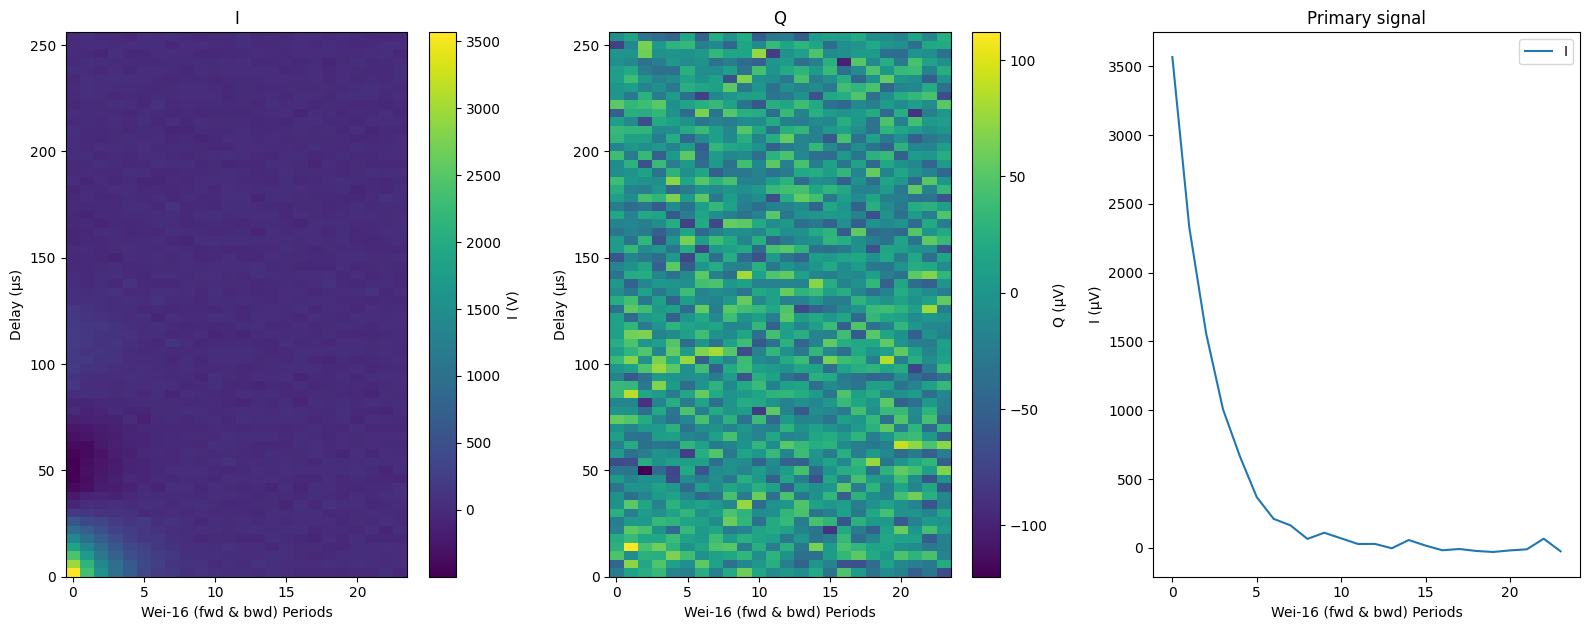

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 288.71s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 289.34s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\wei16\experiment_0037
Experiment with t0=10000.0 complete!


In [ ]:
# sequence time constants
loschmidt_expt = True # whether to do forward and backward sequence for loschmidt echo test

for t0 in (np.linspace(5.0, 10.0, 3)*u.us) :
    print("Testing t0=" + str(t0) + " now.")

    # u0=1; v=0; w=0 # DQ Hamiltonian
    uα=0; vα=-0.5; wα=0.5 # Dipole Hamiltonian
    uβ=0; vβ=0.5; wβ=-0.5 # Dipole Hamiltonian
    a=0; b=0; c=0
    c2=.05
    uα*=c2; vα*=c2; wα*=c2
    uβ*=c2; vβ*=c2; wβ*=c2

    p1 = settings.pulse_length
    t1 = t0*(1-c-vα+wα);   t2 = t0*(1+b-uα+vα);   t3 = t0*(1-a+uα-wα)
    t1p = t0*(1-c-vα+wα);  t2p = t0*(1-b-uα+vα);  t3p = t0*(1-a+uα-wα)
    t1e = t1 + (p1/2) # start & end t1.

    t1β = t0*(1-c-vβ+wβ);   t2β = t0*(1+b-uβ+vβ);   t3β = t0*(1-a+uβ-wβ)
    t1pβ = t0*(1-c-vβ+wβ);  t2pβ = t0*(1-b-uβ+vβ);  t3pβ = t0*(1-a+uβ-wβ)
    t1eβ = t1β + (p1/2) # start & end t1.

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-6.5, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if rho0 == "X": expt.add_pulse(phase=90, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=0, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    wei16_bw_delays = np.array([t1eβ,t2β,2*t3β,t2pβ,t1pβ + t1pβ,t2β,2*t3pβ,t2pβ,t1β +
                            t1β,t2pβ,2*t3pβ,t2β,t1pβ + t1pβ,t2pβ,2*t3β,t2β,t1eβ]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,24,1)
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    if loschmidt_expt:
        expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_bw_delays, repetitions=period_list)
        expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5*u.us)
    if rho0 == "X": expt.add_pulse(phase=270, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=180, element=settings.res_key)
    elif rho0 == "Z": pass

    expt.add_delay(1*u.ms)
    expt.add_pulse(element=settings.res_key)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with t0=" + str(t0) + " complete!")
    time.sleep(10)

Completed fitting experiments:
delay=5.0μs -> tau=3337.404μs
delay=7.5μs -> tau=2231.223μs
delay=10.0μs -> tau=1627.409μs


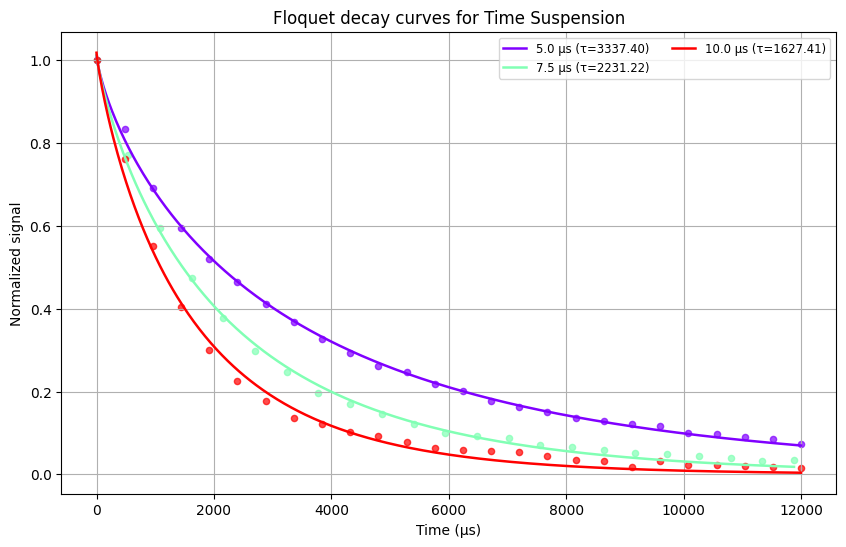

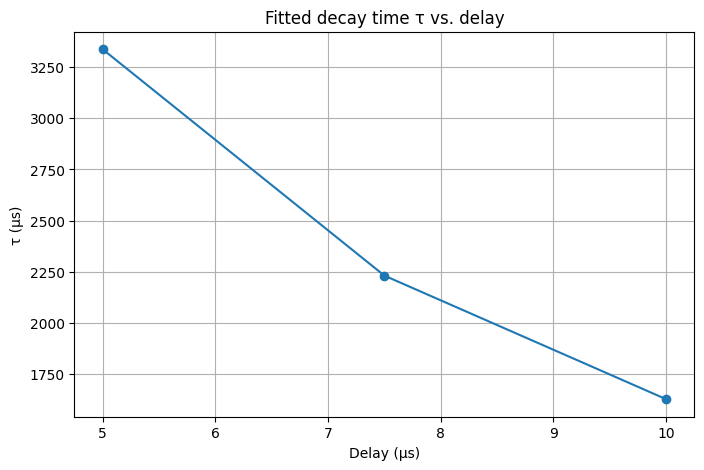

In [60]:
delay_us = np.arange(5.0, 10.1, 2.5)
experiment_ids = np.arange(35, 38)

if len(delay_us) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

colors = plt.cm.rainbow(np.linspace(0, 1, len(delay_us)))

def stretched_exp(x, A, tau, beta):
    return A * np.exp(-(x / tau) ** beta)

all_taus = []
all_delays = []

fig, ax = plt.subplots(figsize=(10, 6))

for delay, exp_id, color in zip(delay_us, experiment_ids, colors):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0] / re[0, 0]

    time = periods * (24 * delay)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.0], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    all_taus.append(tau_fit)
    all_delays.append(delay)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, amplitude_fit, tau_fit, beta_fit)

    ax.scatter(time, signal, color=color, s=20, alpha=0.7)
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8,
            label=f"{delay:.1f} μs (τ={tau_fit:.2f})")

ax.set_title("Floquet decay curves for Time Suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Normalized signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_delays, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for delay, tau in zip(all_delays, all_taus):
    print(f"delay={delay:.1f}μs -> tau={tau:.3f}μs")

In [57]:
print(np.arange(0,67,3))

[ 0  3  6  9 12 15 18 21 24 27 30 33 36 39 42 45 48 51 54 57 60 63 66]


### Time Suspension

Testing t0=5000.0 now.
2026-06-04 12:24:29,478 - qm - INFO     - Performing health check
2026-06-04 12:24:29,482 - qm - INFO     - Cluster healthcheck completed successfully.
using period list 0 to 100
2026-06-04 12:24:30,571 - qm - INFO     - Clearing queue
2026-06-04 12:24:30,586 - qm - INFO     - Adding program to queue.


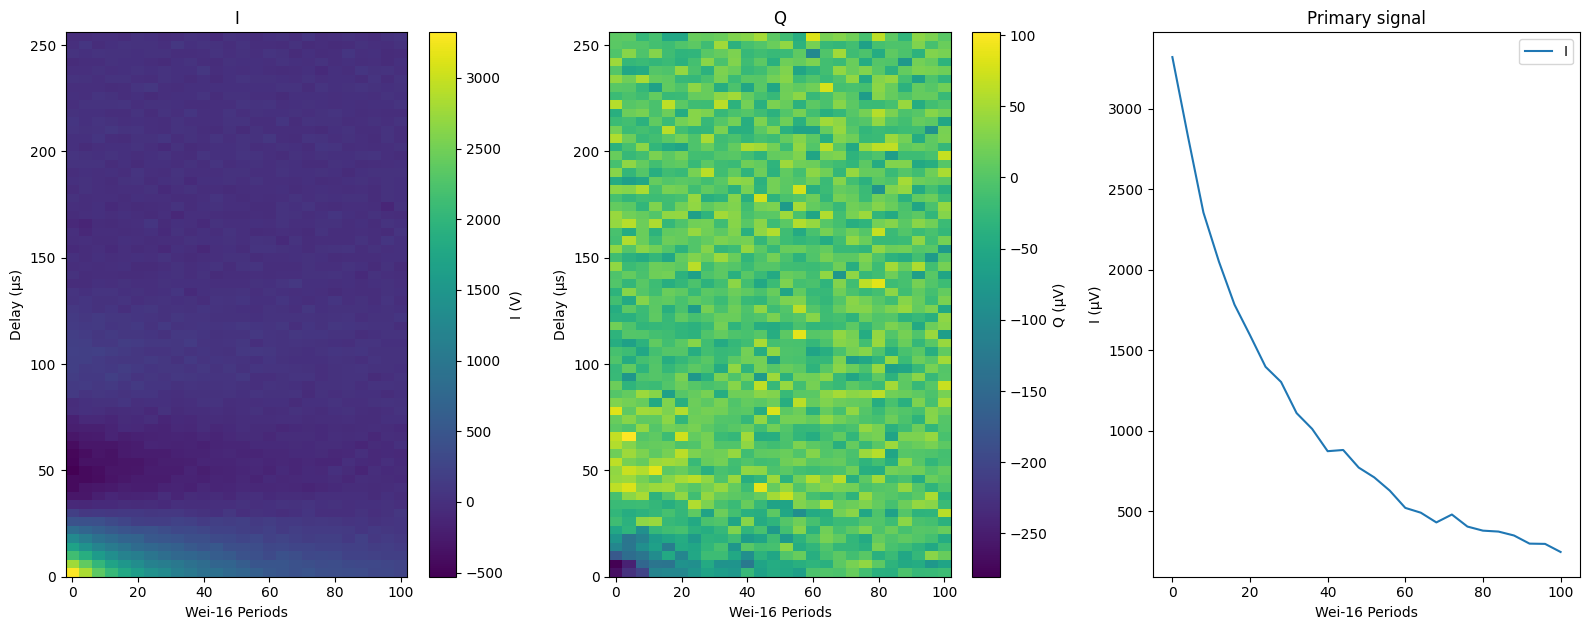

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 312.81s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 313.32s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0035
Experiment with t0=5000.0 complete!
Testing t0=7500.0 now.
2026-06-04 12:31:36,637 - qm - INFO     - Performing health check
2026-06-04 12:31:36,640 - qm - INFO     - Cluster healthcheck completed successfully.
using period list 0 to 66
2026-06-04 12:31:37,217 - qm - INFO     - Clearing queue
2026-06-04 12:31:37,222 - qm - INFO     - Adding program to queue.


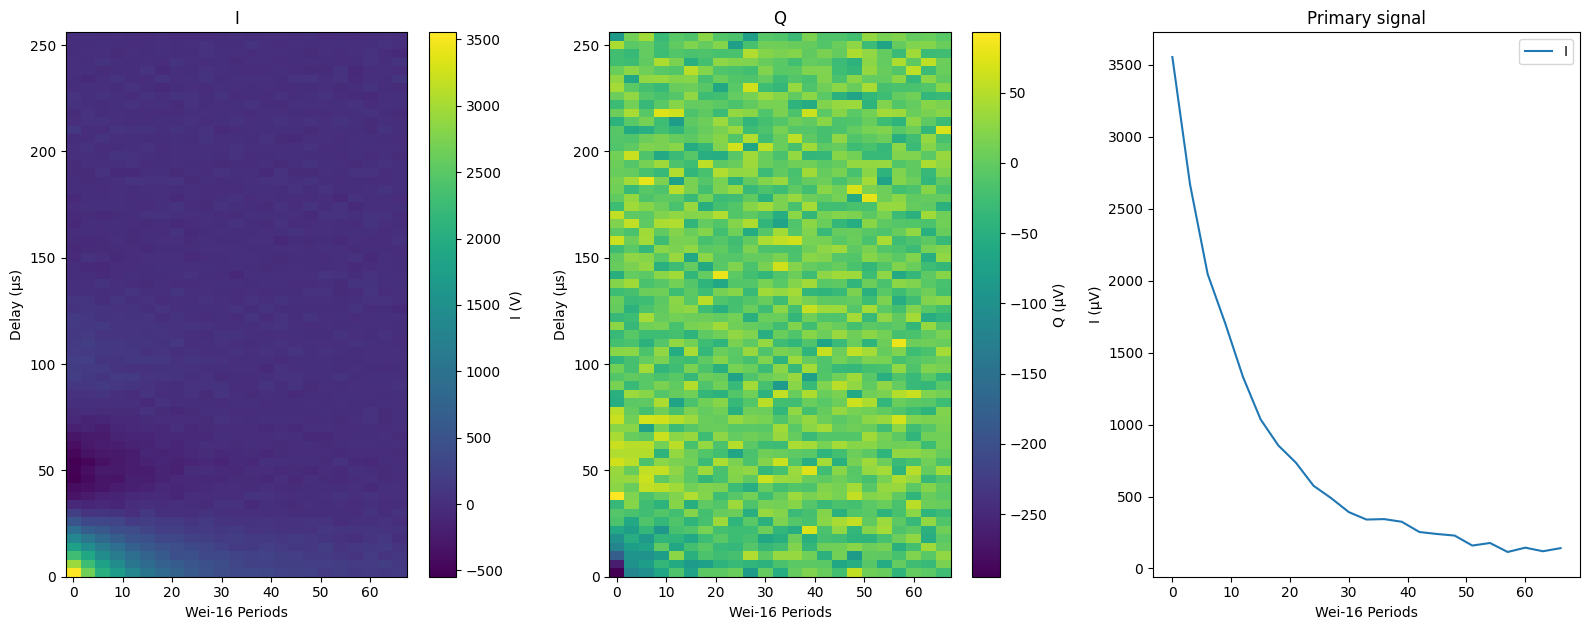

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 276.66s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 277.34s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0036
Experiment with t0=7500.0 complete!
Testing t0=10000.0 now.
2026-06-04 12:37:55,321 - qm - INFO     - Performing health check
2026-06-04 12:37:55,325 - qm - INFO     - Cluster healthcheck completed successfully.
using period list 0 to 50
2026-06-04 12:37:55,888 - qm - INFO     - Clearing queue
2026-06-04 12:37:55,897 - qm - INFO     - Adding program to queue.


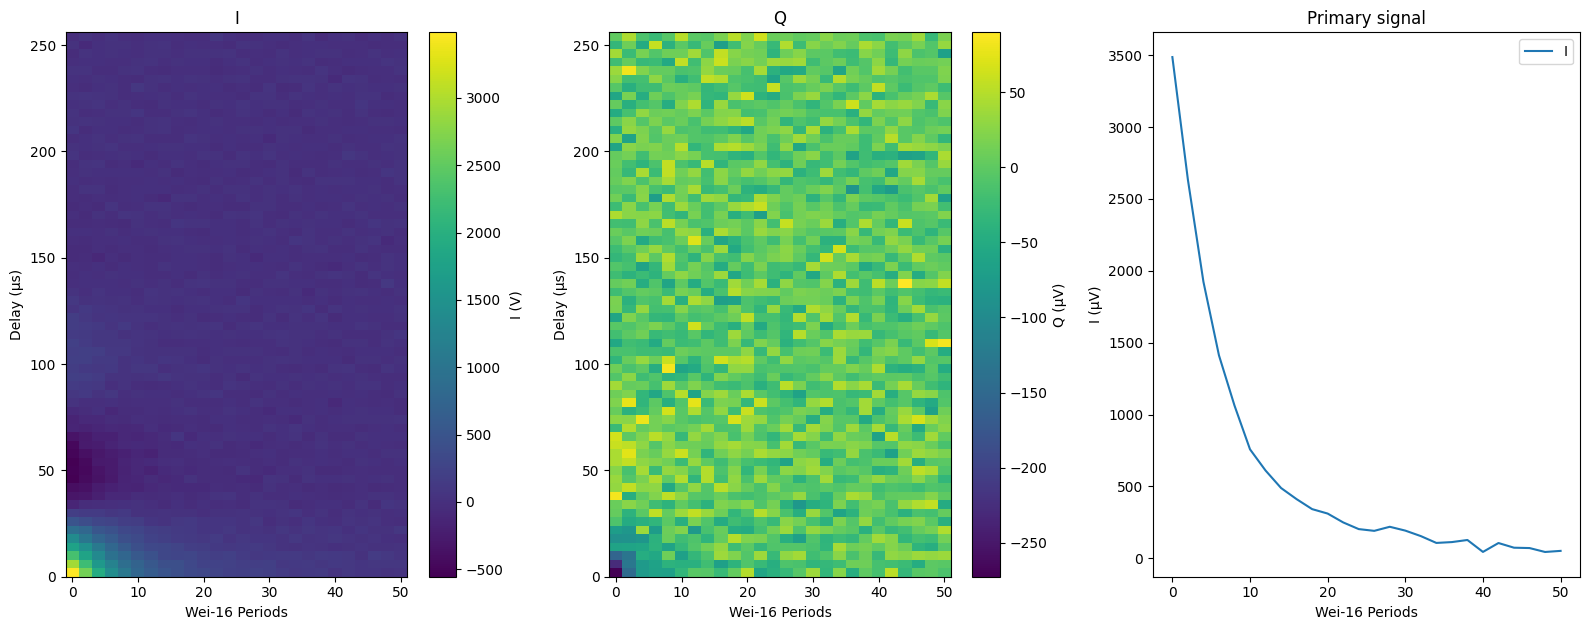

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 312.77s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 313.27s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0037
Experiment with t0=10000.0 complete!


In [ ]:
rho0 = "Z"

for t0 in (np.linspace(5.0, 10.0, 3)*u.us) :
    print("Testing t0=" + str(t0) + " now.")

    # u0=1; v=0; w=0 # DQ Hamiltonian
    u0=0; v=0; w=0 # Dipole Hamiltonian
    a=0; b=0; c=0
    u0*=c2; v*=c2; w*=c2

    p1 = settings.pulse_length
    t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
    t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
    t1e = t1 + (p1/2) # start & end t1.

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-5.0, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_bw_phases = np.array([90,0,0,90,  90,0,0,90,  270,180,180,270,  270,180,180,270])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,51,2)
    if t0 == 5.0*u.us:
        period_list = np.arange(0,101,4)
        print("using period list 0 to 100")
    elif t0 == 7.5*u.us:
        period_list = np.arange(0,67,3)
        print("using period list 0 to 66")
    else:
        period_list = np.arange(0,51,2)
        print("using period list 0 to 50")
    
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    # if loschmidt_expt:
        # expt.add_floquet_sequence(phases=wei16_bw_phases, delays=wei16_delays, repetitions=period_list)
        # expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with t0=" + str(t0) + " complete!")
    time.sleep(10)

Completed fitting experiments:
delay=5.0μs -> tau=3337.404μs
delay=7.5μs -> tau=2231.223μs
delay=10.0μs -> tau=1627.409μs


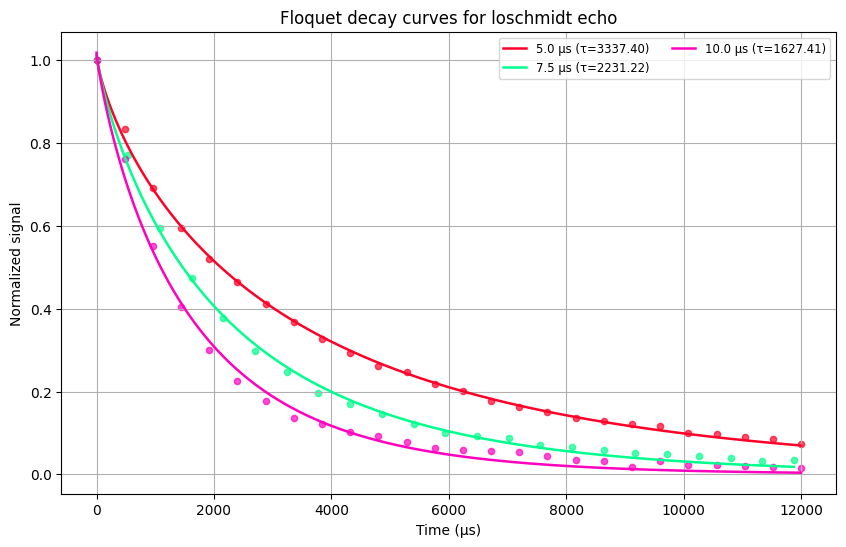

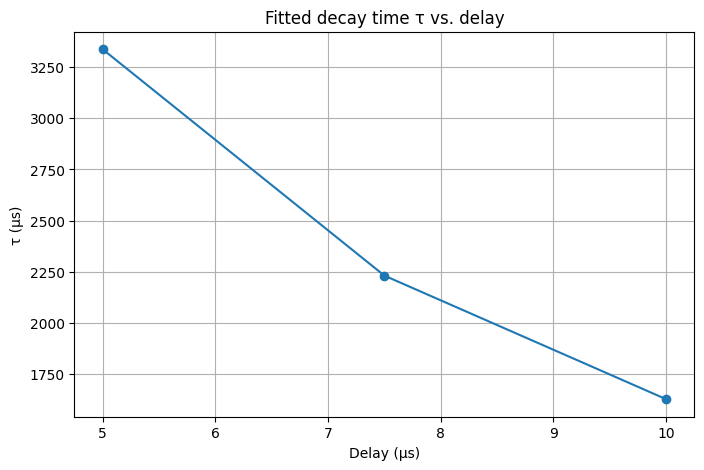

In [ ]:
delay_us = np.arange(5.0, 10.1, 2.5)
experiment_ids = np.arange(35, 38)

if len(delay_us) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(delay_us)))

def stretched_exp(x, A, tau, beta):
    return A * np.exp(-(x / tau) ** beta)

all_taus = []
all_delays = []

fig, ax = plt.subplots(figsize=(10, 6))

for delay, exp_id, color in zip(delay_us, experiment_ids, colors):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0] / re[0, 0]

    time = periods * (24 * delay)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.0], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    all_taus.append(tau_fit)
    all_delays.append(delay)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, amplitude_fit, tau_fit, beta_fit)

    ax.scatter(time, signal, color=color, s=20, alpha=0.7)
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8,
            label=f"{delay:.1f} μs (τ={tau_fit:.2f})")

ax.set_title("Floquet decay curves for time suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Normalized signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_delays, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for delay, tau in zip(all_delays, all_taus):
    print(f"delay={delay:.1f}μs -> tau={tau:.3f}μs")

### Optimized Params

In [ ]:
t0 = 10.0 * u.us
# u0=1; v=0; w=0 # DQ Hamiltonian
u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
a=0; b=0; c=0
c2 = -.02
u0*=c2; v*=c2; w*=c2

print(f"",(u0-w),"SxSx + ",(v-u0),"SySy + ",(w-v),"SzSz")
p1 = settings.pulse_length
t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
t1e = t1 + (p1/2) # starting and ending t1 accounts for p1 subtraction below

# Pine-8 sequence pattern for engineering H=0
wei16_phases = np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                         t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
print(wei16_delays)

total=0
print("Total sequence time: ", np.sum(wei16_delays))

In [67]:
for case in ("Optimized", "Wei0"):
    print(f"Testing case: {case}")
    
    if case == "Optimized":
        t1 = 9.96635504533105*u.us;  t2 = 10.09001011481116*u.us;  t3 = 9.947410980793852*u.us
        t1p= 9.939303861667562*u.us;  t2p= 10.093487031641194*u.us;  t3p= 9.963432965755187*u.us
        t1e = t1 + (p1/2)
    if case == "Wei0":
        t1 = 10*u.us;  t2 = 10*u.us;  t3 = 10*u.us
        t1p= 10*u.us;  t2p= 10*u.us;  t3p= 10*u.us
        t1e = t1 + (p1/2)



Testing case: Optimized
Testing case: Wei0


Testing case: Old Optimized
2026-06-08 20:03:55,707 - qm - INFO     - Performing health check
2026-06-08 20:03:55,707 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-08 20:03:56,757 - qm - INFO     - Clearing queue
2026-06-08 20:03:56,767 - qm - INFO     - Adding program to queue.


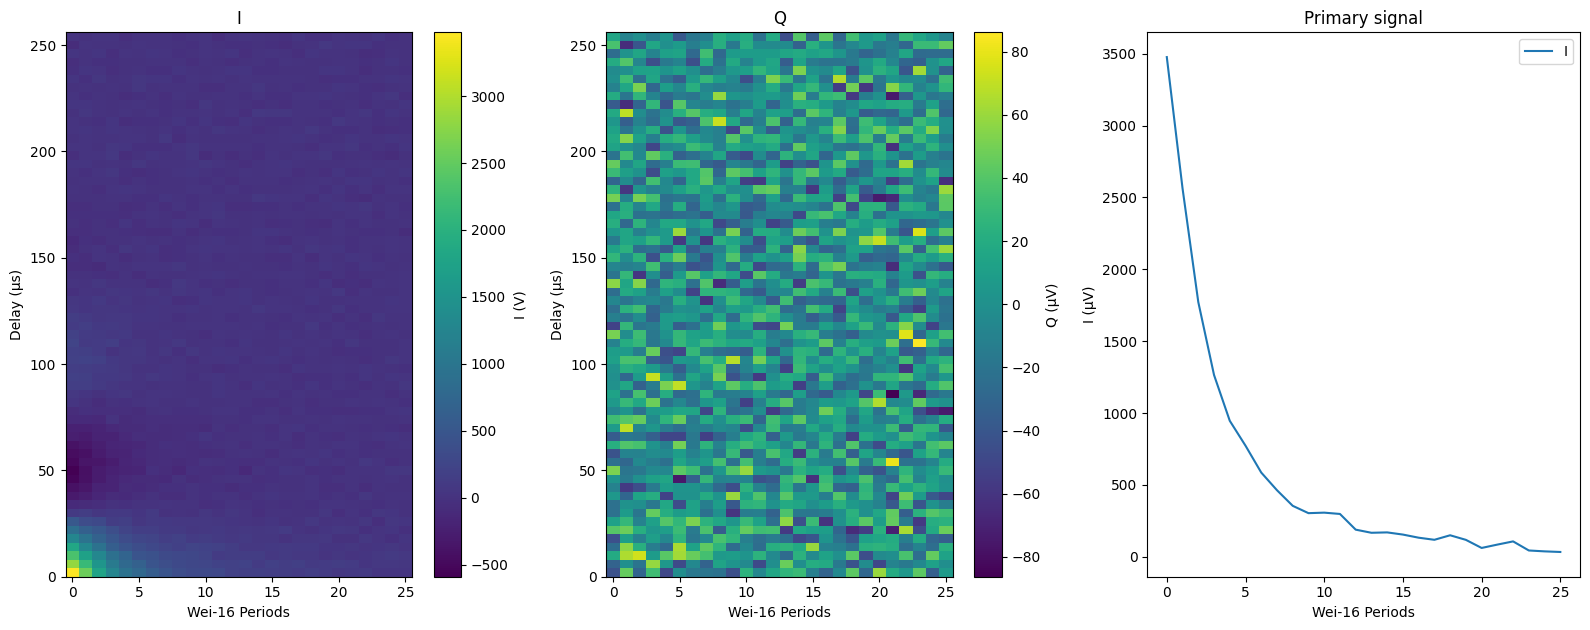

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 312.83s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 313.34s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0076
Experiment with caseOld Optimized complete!


In [188]:
rho0 = "Z"

for case in ("Old Optimized",):
    print(f"Testing case: {case}")

    if case == "Mason Optimized":
        t1,t2,t3, t1p,t2p,t3p=[14497.22714307,15881.02042768,14782.14936686,14744.73555988, 15468.14788537,14626.71961715]
        t1e = t1 + (p1/2)
    if case =="Optimized" :
        t1 = 14.647526347825348*u.us;  t2 = 15.718284749911365*u.us;  t3 = 14.575822807683453*u.us
        t1p= 14.638397404642522*u.us;  t2p= 15.620829354406836*u.us;  t3p= 14.799139335530481*u.us
        t1e = t1 + (p1/2)
    if case == "Old Optimized":
        t1 = 14.891726902443052*u.us;  t2 = 15.29927669680855*u.us;  t3 = 14.91146867734829*u.us
        t1p= 14.806164673134964*u.us;  t2p= 15.29355841919671*u.us;  t3p= 14.797804631068428*u.us
        t1e = t1 + (p1/2)
    if case == "Wei0":
        t1 = 15*u.us;  t2 = 15*u.us;  t3 = 15*u.us
        t1p= 15*u.us;  t2p= 15*u.us;  t3p= 15*u.us
        t1e = t1 + (p1/2)

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-3.75, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1

    period_list = np.arange(0,26,1)
    
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with case" + str(case) + " complete!")

Completed fitting experiments:
case=τ Optimized -> tau=3042.281μs
case=τ=10μs -> tau=1265.671μs


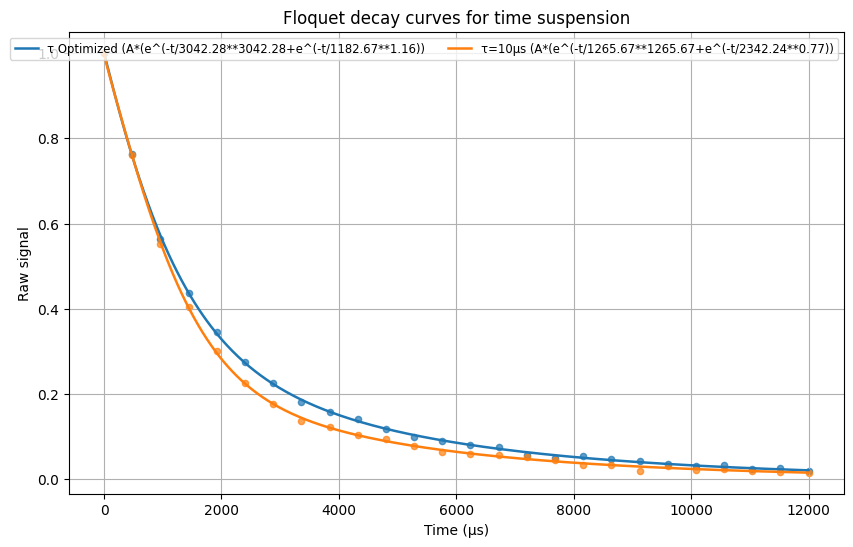

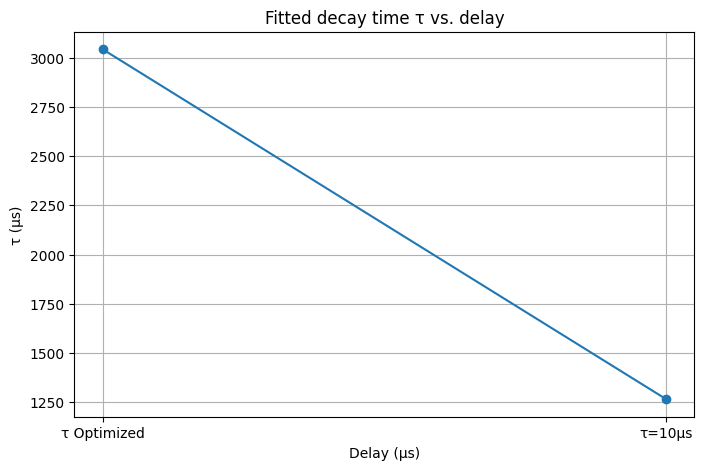

In [ ]:
case = ("τ Optimized", "τ=10μs")
# experiment_ids = (39, 41)
experiment_ids = (42, 37)

if len(case) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

def stretched_exps(x, A, tau, beta, tau2, beta2):
    return A* np.exp(-(x / tau) ** beta) + (1-A) * np.exp(-(x / tau2) ** beta2)

def stretched_exp(x, A, tau, beta):
    return A* np.exp(-(x / tau) ** beta)

all_taus = []
all_cases = []

fig, ax = plt.subplots(figsize=(10, 6))

for thiscase, exp_id in zip(case, experiment_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]/re[0,0]

    time = periods * (24 * 10)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    popt, _ = curve_fit(stretched_exps, x, y, p0=[1.0, 1000, 1.3, 1000, .7], maxfev=10000)
    all_taus.append(tau_fit)
    all_cases.append(thiscase)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, *popt)

    ax.scatter(time, signal, s=20, alpha=0.7)
    # ax.errorbar(time, signal, yerr=(70/re[0,0]), fmt='o')
    ax.plot(x_fit, y_fit, linewidth=1.8,
            label=f"{thiscase} (A*(e^(-t/{tau_fit:.2f}**{tau_fit:.2f}+e^(-t/{tau2_fit:.2f}**{beta2_fit:.2f}))")


ax.set_title("Floquet decay curves for time suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Raw signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_cases, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for case, tau in zip(all_cases, all_taus):
    print(f"case={case} -> tau={tau:.3f}μs")

[3.51434329e+03 6.80608490e+03 7.06382022e-01]
[3.48874768e+03 6.54353737e+03 7.67720527e-01]
Completed fitting experiments:
case=τ Optimized -> tau=6806.085μs
case=τ=5μs -> tau=6543.537μs


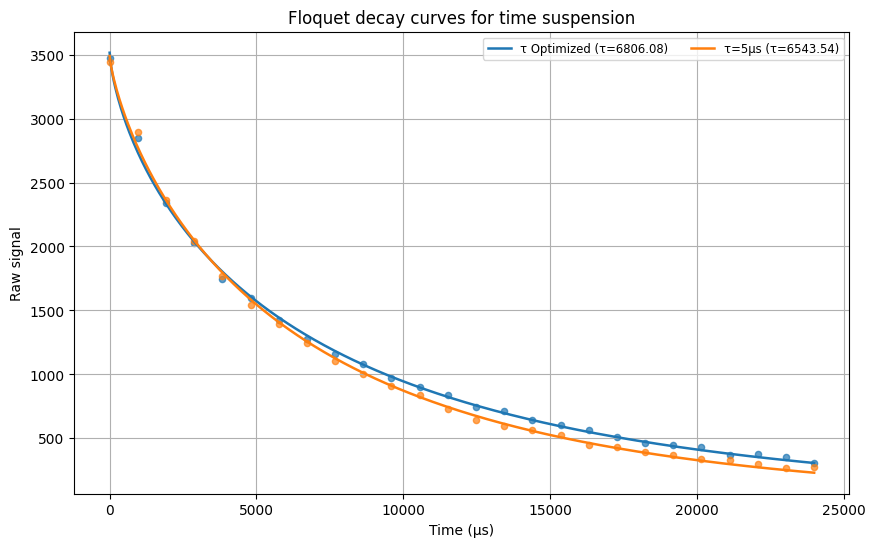

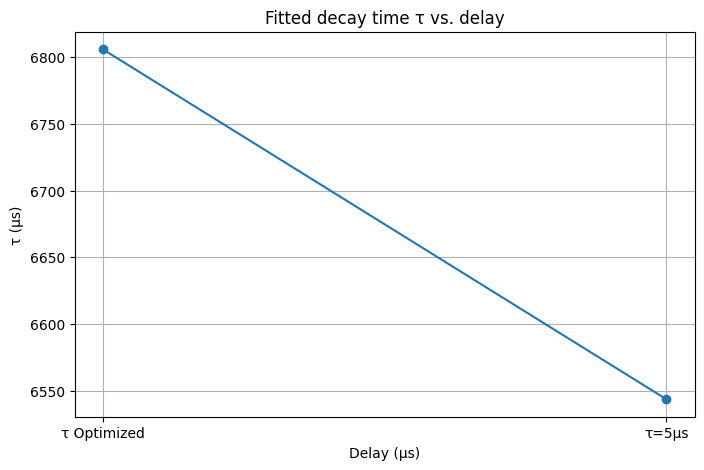

In [ ]:
case = ("τ Optimized", "τ=5μs")
# experiment_ids = (39, 41)
experiment_ids = (43, 44)

if len(case) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

def stretched_exp(x, A, tau, beta):
    return A * np.exp(-(x / tau) ** beta)

all_taus = []
all_cases = []

fig, ax = plt.subplots(figsize=(10, 6))

for thiscase, exp_id in zip(case, experiment_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]

    time = periods * (24 * 10)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 0.05], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    all_taus.append(tau_fit)
    all_cases.append(thiscase)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, amplitude_fit, tau_fit, beta_fit)

    ax.scatter(time, signal, s=20, alpha=0.7)
    # ax.errorbar(time, signal, yerr=(70/re[0,0]), fmt='o')
    ax.plot(x_fit, y_fit, linewidth=1.8,
            label=f"{thiscase} (τ={tau_fit:.2f})")
    print(popt)


ax.set_title("Floquet decay curves for time suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Raw signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_cases, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for case, tau in zip(all_cases, all_taus):
    print(f"case={case} -> tau={tau:.3f}μs")

In [140]:
rho0 = "Z"

for case in ("Wei0", "Optimized"):
    print(f"Testing case: {case}")

    if case == "Optimized":
        t1 = 14.891726902443052*u.us;  t2 = 15.29927669680855*u.us;  t3 = 14.91146867734829*u.us
        t1p= 14.806164673134964*u.us;  t2p= 15.29355841919671*u.us;  t3p= 14.797804631068428*u.us
        t1e = t1 + (p1/2)
    if case == "Wei0":
        t1 = 15*u.us;  t2 = 15*u.us;  t3 = 15*u.us
        t1p= 15*u.us;  t2p= 15*u.us;  t3p= 15*u.us
        t1e = t1 + (p1/2)

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-5.0, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_bw_phases = np.array([90,0,0,90,  90,0,0,90,  270,180,180,270,  270,180,180,270])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1

    period_list = np.arange(0,26,1)
    
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    # if loschmidt_expt:
        # expt.add_floquet_sequence(phases=wei16_bw_phases, delays=wei16_delays, repetitions=period_list)
        # expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with case: " + str(case) + " complete!")

Testing case: Wei0
2026-06-04 15:47:11,337 - qm - INFO     - Performing health check
2026-06-04 15:47:11,352 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-04 15:47:12,290 - qm - INFO     - Clearing queue
2026-06-04 15:47:12,307 - qm - INFO     - Adding program to queue.


KeyboardInterrupt: 

[6.31606200e-01 5.37753528e+02 1.23026935e+00 1.50269758e+03
 8.64132221e-01]
[6.31986820e-01 5.16344554e+02 1.35470422e+00 1.29708259e+03
 8.40779220e-01]
Completed fitting experiments:
case=τ Optimized -> tau=748.497μs
case=τ = 15μs -> tau=685.324μs


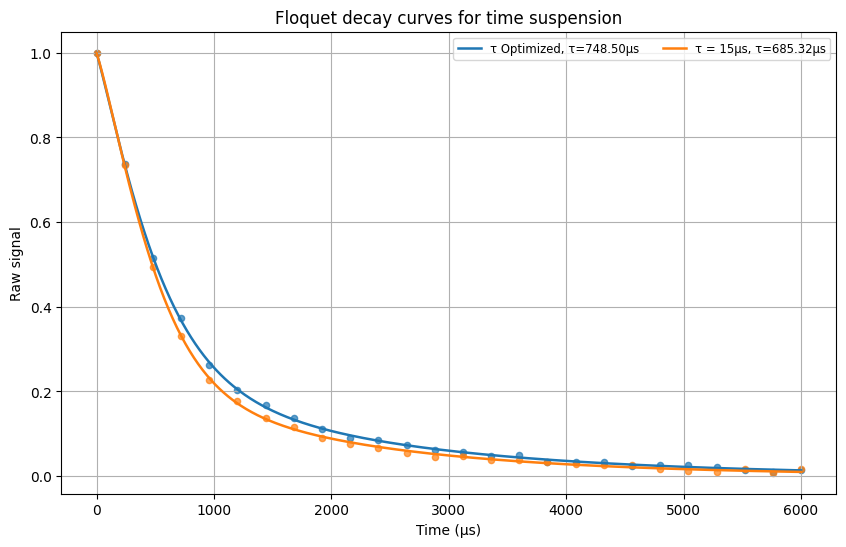

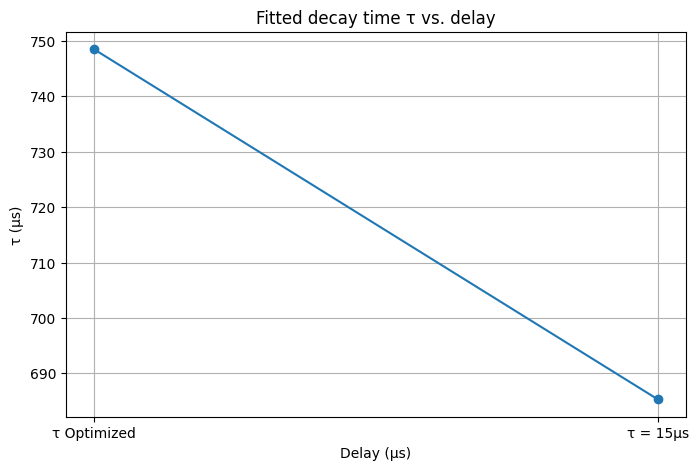

In [168]:
case = ("τ Optimized", "τ = 15μs")
# experiment_ids = (39, 41)
experiment_ids = (46, 45)

if len(case) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

def stretched_exps(x, A, tau, beta, tau2, beta2):
    return A* np.exp(-(x / tau) ** beta) + (1-A) * np.exp(-(x / tau2) ** beta2)

def stretched_exp(x, A, tau, beta):
    return A* np.exp(-(x / tau) ** beta)

all_taus = []
all_cases = []

fig, ax = plt.subplots(figsize=(10, 6))

for thiscase, exp_id in zip(case, experiment_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]/re[0,0]

    time = periods * (24 * 10)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    popt, _ = curve_fit(stretched_exps, x, y, p0=[1.0, 1000, 1.3, 1000, .7], maxfev=10000)
    all_taus.append(tau_fit)
    all_cases.append(thiscase)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exps(x_fit, *popt)

    ax.scatter(time, signal, s=20, alpha=0.7)
    # ax.errorbar(time, signal, yerr=(70/re[0,0]), fmt='o')
    ax.plot(x_fit, y_fit, linewidth=1.8,
            label=f"{thiscase}, τ={tau_fit:.2f}μs")
    print(popt)


ax.set_title("Floquet decay curves for time suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Raw signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_cases, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for case, tau in zip(all_cases, all_taus):
    print(f"case={case} -> tau={tau:.3f}μs")

# StaBerYXX

In [44]:
t0 = 5.0 * u.us
# u0=1; v=0; w=0 # DQ Hamiltonian
u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
a=0; b=0; c=0
c2 = .1
u0*=c2; v*=c2; w*=c2

print(f"",(u0-w),"SxSx + ",(v-u0),"SySy + ",(w-v),"SzSz")
p1 = settings.pulse_length
tx = t0*(1+a+u0-w);   ty = t0*(1+b+v-u0);  tz = t0*(1+c+w-v)
txp= t0*(1-a+u0-w);   typ= t0*(1-b+v-u0);  tzp= t0*(1+c+w-v)

# StaberYXX sequence pattern for engineering H
staberyxx_phases = np.array([90,0,0,  270,0,0,  180,180,90,  180,180,270])
staberyxx_delays = np.array([tz/3 + p1/2, txp, ty, tx, 2/3*tz, typ, 2*tzp,
                         2/3*tz, tx, ty, txp, tz/3 + p1/2]) - p1

print(staberyxx_delays)
print("Total sequence time: ", np.sum(staberyxx_delays))

 -0.05 SxSx +  -0.05 SySy +  0.1 SzSz
[1213.33333333 3510.         3510.         3510.         2426.66666667
 3510.         9760.         2426.66666667 3510.         3510.
 3510.         1213.33333333]
Total sequence time:  41610.0


Testing c2=0.1 now.
2026-05-29 14:32:29,356 - qm - INFO     - Performing health check
2026-05-29 14:32:29,372 - qm - INFO     - Cluster healthcheck completed successfully.
2026-05-29 14:32:30,237 - qm - INFO     - Clearing queue
2026-05-29 14:32:30,245 - qm - INFO     - Adding program to queue.


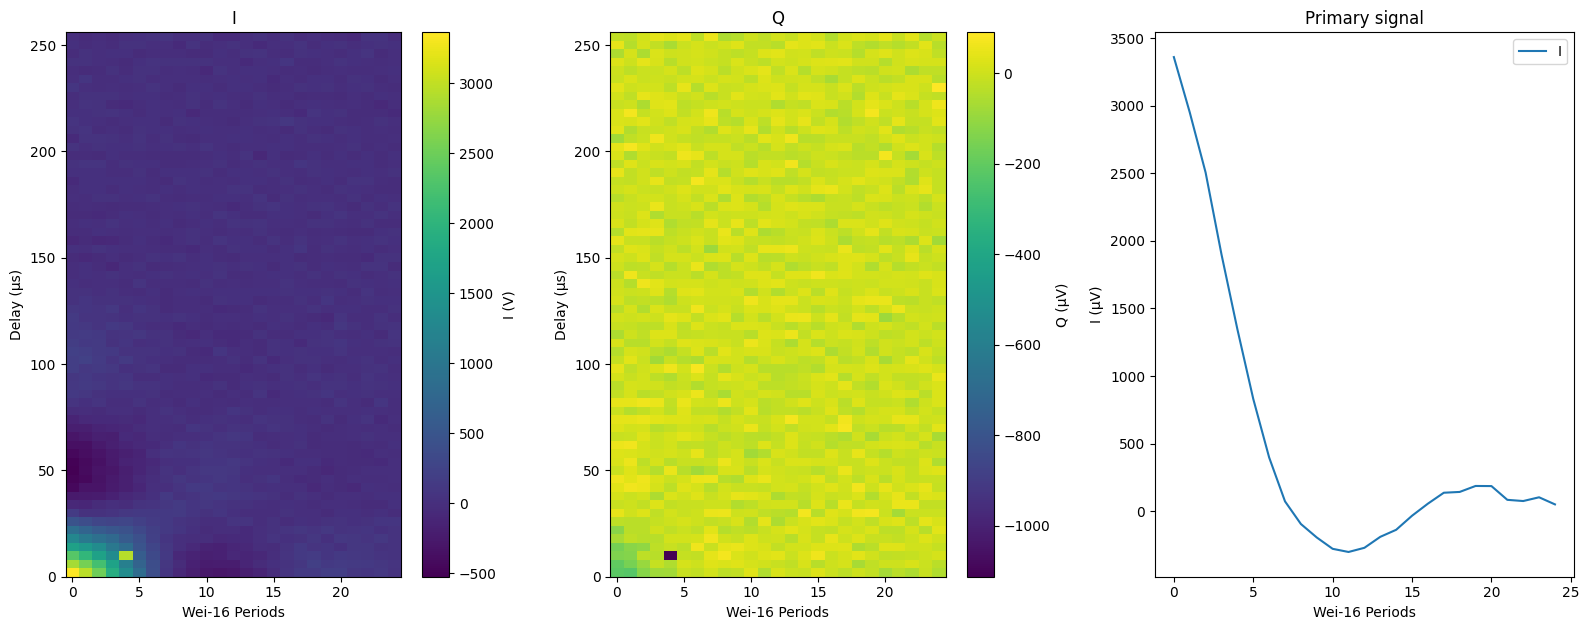

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.28s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.78s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.28s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0031
Experiment with c2=0.1 complete!


In [25]:
rho0 = "X"

for c2 in (.1,):
    print("Testing c2=" + str(c2) + " now.")

    t0 = 5.0 * u.us
    # u0=1; v=0; w=0 # DQ Hamiltonian
    u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
    a=0; b=0; c=0
    u0*=c2; v*=c2; w*=c2

    p1 = settings.pulse_length
    t1 = t0*(1-c-v+w);   t2 = t0*(1+b-u0+v);   t3 = t0*(1-a+u0-w)
    t1p = t0*(1-c-v+w);  t2p = t0*(1-b-u0+v);  t3p = t0*(1-a+u0-w)
    t1e = t1 + (p1/2) # start & end t1.

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-4.5, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # Wei16 sequence pattern for engineering H
    wei16_phases =    np.array([0,90,90,0,  0,90,90,0,  180,270,270,180,  180,270,270,180])
    wei16_bw_phases = np.array([90,0,0,90,  90,0,0,90,  270,180,180,270,  270,180,180,270])
    wei16_delays = np.array([t1e,t2,2*t3,t2p,t1p + t1p,t2,2*t3p,t2p,t1 +
                            t1,t2p,2*t3p,t2,t1p + t1p,t2p,2*t3,t2,t1e]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,25,1)
    expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
    expt.update_sweep_label("Wei-16 Periods")
    # if loschmidt_expt:
        # expt.add_floquet_sequence(phases=wei16_bw_phases, delays=wei16_delays, repetitions=period_list)
        # expt.update_sweep_label("Wei-16 (fwd & bwd) Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with c2=" + str(c2) + " complete!")
    time.sleep(10)


Exp 34 | c2=0.05 | A=1.000, b1=-0.729, b2=2.192, c=8.168, d=32.425, e=24887.429


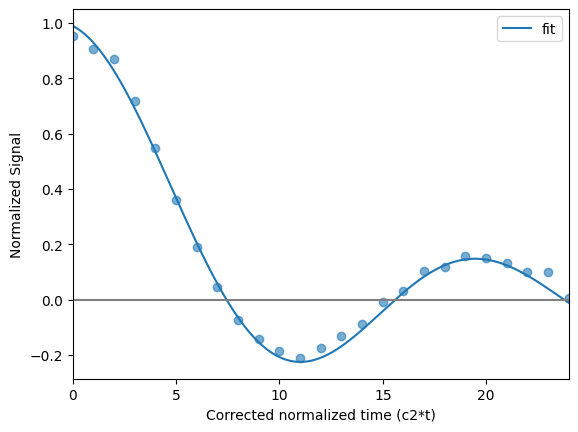

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json

# ---- Gaussian Sinc fit function ----
def damped_moment(t, A, b1, b2, c, d, e):
    fid = A * np.sinc((t-b1)/c) * np.exp(((t-b2)/d)**2 / 2) * np.exp(-t / e)
    return np.array(fid, dtype=float)

# ---- Colors (red → purple) ----

plt.figure()

data_path = settings.save_dir / "experiment_0031/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
signal = re[:, 0] / c02signal

# ---- Fit ----
popt, _ = curve_fit(
    damped_moment,
    periods,
    signal,
    p0=[1.0, 0, 0, 10, 10, 1],
    bounds=([1, -50, -50, 0, 0, 0],[1.2, 50, 50, 1000, 10000, 9999999])
)

# ---- Fit curve ----
x_fit = np.linspace(min(periods), max(periods), 500)
y_fit = damped_moment(x_fit, *popt)

# ---- Plot ----
plt.scatter(periods, signal, alpha=0.6)
plt.plot(x_fit, y_fit, label="fit")

print(f"Exp {exp_id} | c2={abs(c2_values[i]):.2f} | "
        f"A={popt[0]:.3f}, b1={popt[1]:.3f}, b2={popt[2]:.3f}, c={popt[3]:.3f}, d={popt[4]:.3f}, e={popt[5]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(periods))
plt.xlabel("Corrected normalized time (c2*t)")
plt.ylabel("Normalized Signal")

plt.show()

Testing c2=0.2 now.
2026-05-29 17:30:33,107 - qm - INFO     - Performing health check
2026-05-29 17:30:33,110 - qm - INFO     - Cluster healthcheck completed successfully.
2026-05-29 17:30:33,824 - qm - INFO     - Clearing queue
2026-05-29 17:30:33,832 - qm - INFO     - Adding program to queue.


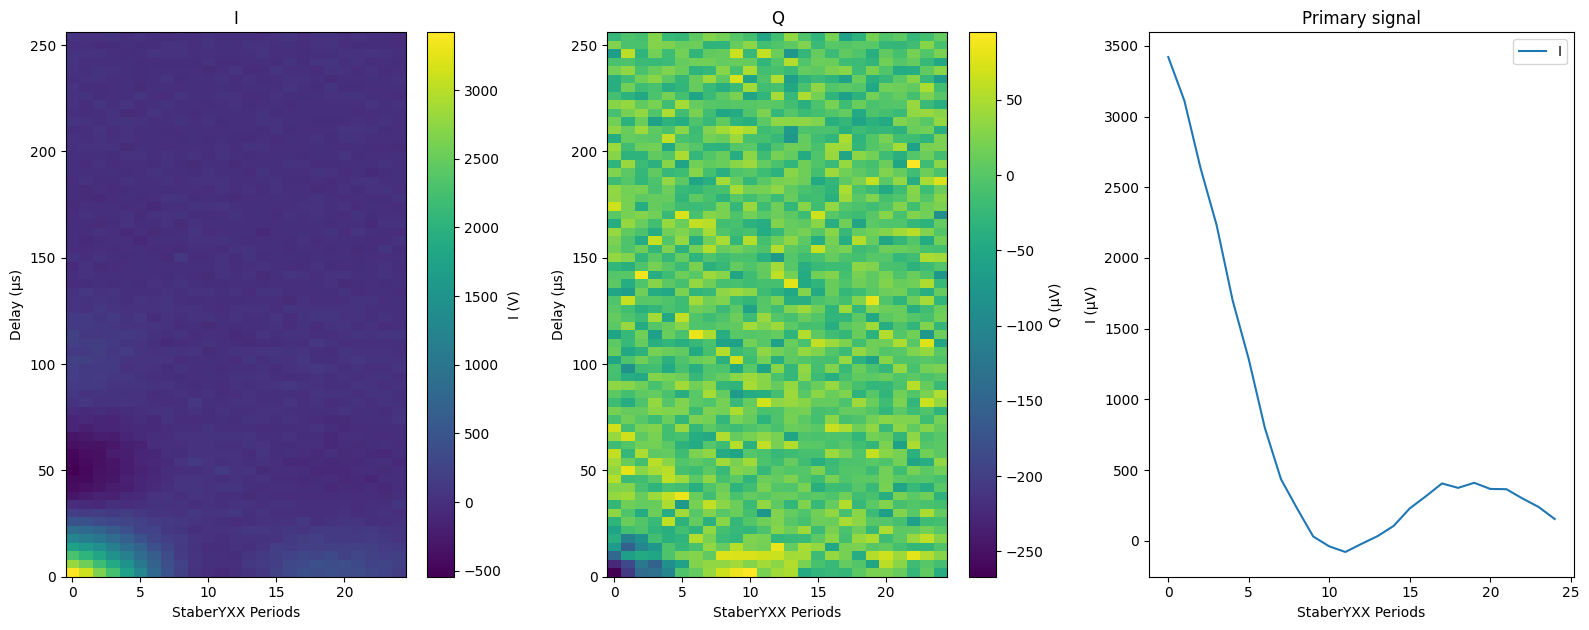

Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.25s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 300.78s
Progress: [##################################################] 100.0% (n=4/4) --> elapsed time: 301.33s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\floquet_expt\experiment_0033
Experiment with c2=0.2 complete!


In [47]:
rho0 = "X"

for c2 in (.2,):
    print("Testing c2=" + str(c2) + " now.")

    t0 = 5.0 * u.us
    # u0=1; v=0; w=0 # DQ Hamiltonian
    u0=0; v=-0.5; w=0.5 # Dipole Hamiltonian
    a=0; b=0; c=0
    u0*=c2; v*=c2; w*=c2

    p1 = settings.pulse_length
    tx = t0*(1+a+u0-w);   ty = t0*(1+b+v-u0);  tz = t0*(1+c+w-v)
    txp= t0*(1-a+u0-w);   typ= t0*(1-b+v-u0);  tzp= t0*(1+c+w-v)

    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)

    fc_elements = (settings.res_key, settings.helper_key)
    expt.add_frame_change(angle=-4.5, elements=fc_elements)

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # StaberYXX sequence pattern for engineering H
    staberyxx_phases = np.array([90,0,0,  270,0,0,  180,180,90,  180,180,270])
    staberyxx_delays = np.array([tz/3 + p1/2, txp, ty, tx, 2/3*tz, typ, 2*tzp,
                            typ, 2/3*tz, tx, ty, txp, tz/3 + p1/2]) - p1
    # evolve for up to 24 periods, 0 to 24
    period_list = np.arange(0,25,1)
    expt.add_floquet_sequence(phases=staberyxx_phases, delays=staberyxx_delays, repetitions=period_list)
    expt.update_sweep_label("StaberYXX Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay()
    # expt.simulate_experiment()

    print("Experiment with c2=" + str(c2) + " complete!")
    time.sleep(10)


Exp 34 | c2=0.05 | A=1.000, b1=-1.291, b2=-0.372, c=8.330, d=22.882, e=27979.590


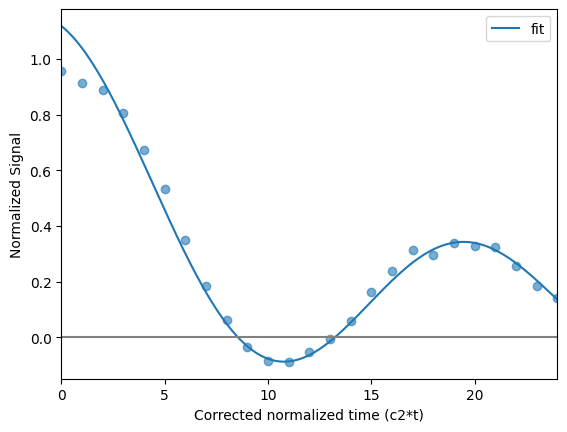

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json

# ---- Gaussian Sinc fit function ----
def damped_moment(t, A, b1, b2, c, d, e,f):
    fid = A * np.sinc((t-b1)/c) * np.exp(((t-b2)/d)**2 / 2) * np.exp(-t / e) +f
    return np.array(fid, dtype=float)

# ---- Colors (red → purple) ----

plt.figure()

data_path = settings.save_dir / "experiment_0033/data.json"

with open(data_path, "r") as f:
    data_dict = json.load(f)

re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
signal = re[:, 0] / c02signal

# ---- Fit ----
popt, _ = curve_fit(
    damped_moment,
    periods,
    signal,
    p0=[1.0, 0, 0, 10, 10, 1,0],
    bounds=([1, -50, -50, 0, 0, 0,-10],[1.2, 50, 50, 1000, 10000, 9999999,10])
)

# ---- Fit curve ----
x_fit = np.linspace(min(periods), max(periods), 500)
y_fit = damped_moment(x_fit, *popt)

# ---- Plot ----
plt.scatter(periods, signal, alpha=0.6)
plt.plot(x_fit, y_fit, label="fit")

print(f"Exp {exp_id} | c2={abs(c2_values[i]):.2f} | "
        f"A={popt[0]:.3f}, b1={popt[1]:.3f}, b2={popt[2]:.3f}, c={popt[3]:.3f}, d={popt[4]:.3f}, e={popt[5]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(periods))
plt.xlabel("Corrected normalized time (c2*t)")
plt.ylabel("Normalized Signal")

plt.show()